[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunilmogadati/systems-in-production/blob/main/implementation/notebooks/AI_Engineer_Accelerator_ML%20(Machine%20Learning)_Fundamentals.ipynb)

# ML Fundamentals — The Operating System Behind Every Algorithm

**AI (Artificial Intelligence) Engineer Accelerator**
**Author:** Sunil Mogadati
**Community:** [WorkWise Community on Skool](https://www.skool.com/workwise)

---

**Prerequisites:** Step 1 (Linear Regression), Step 2 (Logistic Regression), Math for AI

## Objective

By the end of this notebook, you will be able to:

1. **Run the full ML (Machine Learning) lifecycle** — from raw data to a trained, evaluated, explained, and tracked model
2. **Diagnose model problems** — look at train/test scores and immediately know if the model is overfitting, underfitting, or healthy
3. **Choose the right evaluation metric** — know when accuracy is misleading and which metric (precision, recall, F1, ROC-AUC) matters for your business problem
4. **Explain model predictions to non-technical stakeholders** — use SHAP (SHapley Additive exPlanations) to answer "why did the model predict THIS?"
5. **Track experiments reproducibly** — log every model run to MLflow so you can compare, reproduce, and audit

These 5 skills are what separate someone who can call `model.fit()` from someone who can **build, evaluate, explain, and defend** an ML system in production.

---

**What we cover:**
- The ML lifecycle — the 7-step process behind every ML project
- Bias-variance tradeoff — THE central tension in all of ML
- Overfitting vs underfitting — named, diagnosed, and fixed
- Regularization — L1, L2, ElasticNet (a tax on model complexity)
- Feature engineering — better features beat complex models
- Hyperparameter tuning — GridSearchCV, RandomizedSearchCV
- Evaluation metrics — precision, recall, F1, ROC-AUC (and when each one matters)
- SHAP explainability — "show the stakeholders WHY the model decided that"
- Experiment tracking with MLflow — "git for experiments"
- A full end-to-end pipeline putting it all together

> **How this notebook fits:** Step1 and Step2 taught you specific algorithms (applications).
> This notebook teaches the **cross-cutting concepts** that apply to EVERY algorithm (the operating system).
> Think of it this way — Step1/Step2/future Steps are apps. This notebook is the OS they run on.
>
> **Where this leads:** After this notebook, you are ready for [Project P1: ML Predictor](https://github.com/sunilmogadati/systems-in-production/blob/main/implementation/projects/P1_ML_Predictor.md) — where you apply everything here to a real bank churn prediction problem with your own code.

## Key Terms — Abbreviations Used in This Notebook

Every abbreviation below is explained when first used, but this is your quick reference:

| Abbreviation | Full Form |
|:------------|:----------|
| **AI** | Artificial Intelligence |
| **APIs** | Application Programming Interfaces |
| **API** | Application Programming Interface |
| **AUC** | Area Under the Curve |
| **BERT** | Bidirectional Encoder Representations from Transformers |
| **CI/CD** | Continuous Integration/Continuous Delivery |
| **EDA** | Exploratory Data Analysis |
| **GPT** | Generative Pre-trained Transformer |
| **KNN** | K-Nearest Neighbors |
| **LLMs** | Large Language Models |
| **ML** | Machine Learning |
| **MSE** | Mean Squared Error |
| **PCA** | Principal Component Analysis |
| **RAG** | Retrieval-Augmented Generation |
| **REST** | Representational State Transfer |
| **RMSE** | Root Mean Squared Error |
| **ROC** | Receiver Operating Characteristic |


## Glossary — Abbreviations Used in This Notebook

| Abbreviation | Full Form | Plain English |
|-------------|-----------|---------------|
| **L1** | L1 Regularization (Lasso) | Penalty that can zero out unimportant features |
| **L2** | L2 Regularization (Ridge) | Penalty that shrinks all weights toward zero |
| **EN** | ElasticNet | Combines L1 and L2 — best of both |
| **HP** | Hyperparameter | A setting YOU choose (not learned from data) |
| **CV** | Cross-Validation | Testing on multiple data splits for reliable scores |
| **SHAP** | SHapley Additive exPlanations | Each feature's "fair share" of the prediction |
| **FE** | Feature Engineering | Creating better inputs from raw data |
| **MLflow** | MLflow | Open-source experiment tracking — "git for models" |
| **EDA** | Exploratory Data Analysis | Looking at data before modeling |
| **MSE** | Mean Squared Error | Average of squared prediction errors |
| **RMSE** | Root Mean Squared Error | Square root of MSE — same units as target |
| **R²** | R-squared | How much better than guessing the average (0 to 1) |
| **ROC-AUC** | Receiver Operating Characteristic — Area Under Curve | Single score for classifier quality |
| **SMOTE** | Synthetic Minority Over-sampling Technique | Creates synthetic examples of the rare class |

#### Math Symbols Used in This Notebook

| Symbol | How to Read It | What It Means |
|--------|---------------|---------------|
| **λ** | "lambda" | Regularization strength (called `alpha` in sklearn) |
| **α** | "alpha" | Same as λ — sklearn uses `alpha` instead of `lambda` |
| **‖w‖₁** | "L1 norm of w" | Sum of absolute values of weights |
| **‖w‖₂²** | "L2 norm squared" | Sum of squared weights |
| **ŷ** | "y-hat" | The model's predicted value |

---

## Table of Contents

| # | Section | What You'll Learn | References |
|---|---------|-------------------|------------|
| 1 | The ML Lifecycle | 7-step process, supervised vs unsupervised, lifecycle diagram | Step1 Parts 1-6, Step2 Parts 1-8 |
| 2 | Bias-Variance Tradeoff | Dartboard analogy, polynomial overfitting, U-shaped error curve, learning curves | **NEW** (never taught) |
| 3 | Overfitting vs Underfitting | Named diagnosis, decision tree demo, diagnostic dashboard, checklist | Step1 Part 9, Step1 Exercise 2 |
| 4 | Regularization | L1/L2/ElasticNet, alpha sweep, coefficient comparison, classification regularization | **NEW** |
| 5 | Feature Engineering | Correlation, SelectKBest, encoding, missing values, imbalanced classes | Step1 Parts 7-8, Step2 Part 5 |
| 6 | Hyperparameter Tuning | GridSearchCV, RandomizedSearchCV, Pipeline, tuning workflow | **NEW** |
| 7 | SHAP Explainability | TreeExplainer, force plot, summary plot, dependence plot | **NEW** (P1 requirement) |
| 8 | Experiment Tracking | MLflow logging, run comparison, MLflow vs W&B | **NEW** |
| 9 | Putting It All Together | Full pipeline: EDA → FE → baseline → tune → SHAP → MLflow | Sections 1-8 |
| 10 | Self-Check + Map Forward | 12 questions, curriculum connections | All |

In [1]:
# ============================================================
# SETUP — Run this cell first
# ============================================================
# sklearn, numpy, pandas, matplotlib, seaborn are pre-installed in Colab.
# We only need to install shap (explainability) and mlflow (experiment tracking).

!pip install -q shap mlflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clean plot defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

print("Setup complete.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

zsh:1: command not found: pip


Setup complete.
NumPy: 2.4.2
Pandas: 2.3.3


## Architect's Decision Checklist — The ML Project Blueprint

Before touching code, an ML engineer makes these decisions. This checklist frames every section in this notebook.

| Phase | Key Decision | What Can Go Wrong |
|:------|:-------------|:------------------|
| **Problem Framing** | Is this actually an ML problem? Could rules/heuristics work? | Building ML for a problem that a 10-line `if/else` solves |
| **Data** | Do I have enough labeled data? Is it representative? | Training on biased data → model that fails on real users |
| **Splitting** | Train/validation/test — how to split? | Data leakage from improper splitting (Section 1-2) |
| **Model Selection** | Simple model first, then add complexity if needed | Jumping to neural networks when logistic regression would suffice |
| **Evaluation** | Which metric matches the business goal? | Optimizing accuracy on imbalanced data (Section 3-4) |
| **Tuning** | Hyperparameter search strategy? | Overfitting to the validation set via excessive tuning (Section 6) |
| **Explainability** | Can we explain predictions to stakeholders? | Black-box model in a regulated industry (Section 7) |
| **Tracking** | How do we compare experiments? | "Which model was that good one from last Tuesday?" (Section 8) |
| **Deployment** | How does the model get to production? | Model works in notebook, fails in production (Section 9) |

> **The progression:** This notebook covers each phase. The checklist tells you WHERE each section fits in the larger picture.


---

## 1. The ML Lifecycle

Every ML project — from a weekend Kaggle competition to a $10M production system — follows the same 7-step process. Step1 and Step2 already walked you through every step. This section **names** the lifecycle and shows you the map.

### The 7-Step ML Lifecycle

| Step | What Happens | Where You Did This |
|------|-------------|-------------------|
| **1. Problem Definition** | Define what you're predicting and why | Step1: "predict house prices" / Step2: "predict survival" |
| **2. Data Collection** | Gather data (databases, APIs (Application Programming Interfaces), files) | Step1: California Housing / Step2: Titanic |
| **3. EDA + Feature Engineering** | Explore data, create useful features, handle missing values | Step1 Parts 7-8 / Step2 Part 2 |
| **4. Model Selection** | Choose an algorithm (linear? tree? ensemble?) | Step1: LinearRegression / Step2: LogisticRegression |
| **5. Training** | Feed data to the model — `model.fit(X_train, y_train)` | Step1 Part 2 / Step2 Part 2 |
| **6. Evaluation** | Measure performance on held-out test data | Step1 Parts 4-6 / Step2 Parts 3-8 |
| **7. Deploy + Monitor** | Ship it, watch for drift, retrain as needed | the Cloud & MLOps section (MLOps) |

The lifecycle is a **loop**, not a line. Deployment feeds back into data collection (new data arrives), which triggers retraining. The model is never "done."

In [2]:
# ============================================================
# SECTION 1: Hello World — All 7 Lifecycle Steps in 10 Lines
# ============================================================
# Let's execute the entire ML lifecycle on real data, right now.
# Each line maps to a lifecycle step.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Problem = predict median house value
# Step 2: Data = California Housing (built into sklearn)
data = fetch_california_housing()
X, y = data.data, data.target                          # Step 2: Collect

X_train, X_test, y_train, y_test = train_test_split(   # Step 3: Split
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()                              # Step 4: Select
model.fit(X_train, y_train)                             # Step 5: Train
score = r2_score(y_test, model.predict(X_test))         # Step 6: Evaluate
# Step 7: Deploy (the Cloud & MLOps section)

print(f"Test R²: {score:.4f}")
print()
print("That's the ML lifecycle. 7 steps, 10 lines.")
print("Every ML project you'll ever build follows this exact rhythm.")

Test R²: 0.5758

That's the ML lifecycle. 7 steps, 10 lines.
Every ML project you'll ever build follows this exact rhythm.


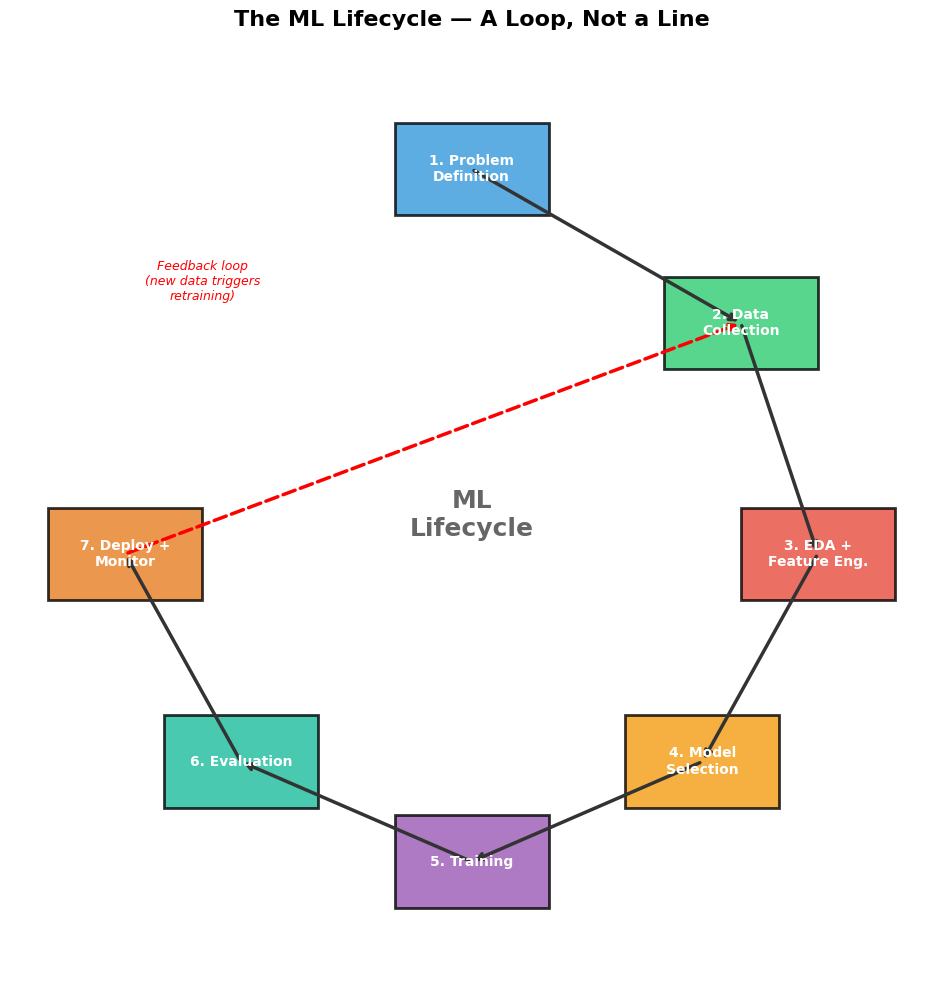

KEY INSIGHT: The lifecycle is a LOOP.
Deployment feeds back into data collection.
Models are never 'done' — they drift as the world changes.

THIS NOTEBOOK covers Steps 3-6 in depth.
Steps 1-2 are domain-specific. Step 7 is the Cloud & MLOps section (MLOps).


In [3]:
# ============================================================
# SECTION 1: The ML Lifecycle — Visualized as a Loop
# ============================================================

# 10x10 square figure — needed so the circular layout doesn't get distorted
fig, ax = plt.subplots(figsize=(10, 10))

# Arrange lifecycle steps in a circle — visual reinforcement that ML is iterative, not linear
steps = [
    ("1. Problem\nDefinition", 0.5, 0.95),
    ("2. Data\nCollection", 0.85, 0.75),
    ("3. EDA +\nFeature Eng.", 0.95, 0.45),
    ("4. Model\nSelection", 0.8, 0.18),
    ("5. Training", 0.5, 0.05),
    ("6. Evaluation", 0.2, 0.18),
    ("7. Deploy +\nMonitor", 0.05, 0.45),
]

# Each step gets a distinct color — visual anchor for referencing specific stages later
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
for i, (label, x, y) in enumerate(steps):
    ax.add_patch(plt.Rectangle((x - 0.1, y - 0.06), 0.2, 0.12,
                                facecolor=colors[i], edgecolor='black',
                                linewidth=2, alpha=0.8, zorder=3))
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', zorder=4)

# Arrows show the forward flow: define -> collect -> explore -> select -> train -> evaluate -> deploy
arrow_props = dict(arrowstyle='->', color='#333333', lw=2.5)
for i in range(len(steps) - 1):
    x1, y1 = steps[i][1], steps[i][2]
    x2, y2 = steps[i+1][1], steps[i+1][2]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_props)

# The feedback arrow is KEY — deployment data triggers retraining. Models drift as the world changes.
ax.annotate('', xy=(steps[1][1], steps[1][2]),
            xytext=(steps[6][1], steps[6][2]),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5, linestyle='--'))
ax.text(0.15, 0.78, 'Feedback loop\n(new data triggers\nretraining)', fontsize=9,
        color='red', ha='center', style='italic')

# Center label anchors the diagram — students recall "ML Lifecycle" when they see this layout
ax.text(0.5, 0.5, 'ML\nLifecycle', ha='center', va='center', fontsize=18,
        fontweight='bold', color='#666666')

# Equal aspect ratio + hidden axes — circle looks like a circle, not an ellipse
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('The ML Lifecycle — A Loop, Not a Line', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("KEY INSIGHT: The lifecycle is a LOOP.")
print("Deployment feeds back into data collection.")
print("Models are never 'done' — they drift as the world changes.")
print()
print("THIS NOTEBOOK covers Steps 3-6 in depth.")
print("Steps 1-2 are domain-specific. Step 7 is the Cloud & MLOps section (MLOps).")

### Supervised vs Unsupervised vs Self-Supervised

| Type | Question It Answers | Example | Algorithm | In This Program |
|------|-------------------|---------|-----------|-----------------|
| **Supervised** | "Given inputs and correct answers, learn the pattern" | Predict house price from features | Linear/Logistic Regression, Trees, Neural Nets | Step1, Step2, this notebook |
| **Unsupervised** | "Find structure in data with NO correct answers" | Group customers by behavior | K-Means, DBSCAN, PCA (Principal Component Analysis) | Step3 (future) |
| **Self-Supervised** | "Create your own labels from the data itself" | Predict next word in a sentence | GPT (Generative Pre-trained Transformer), BERT (Bidirectional Encoder Representations from Transformers), all LLMs (Large Language Models) | the Transformer section (Transformers) |

Self-supervised learning is how ChatGPT and Claude were trained — by predicting the next word in billions of sentences. The "label" is just the next word, which already exists in the text. No human labeling needed.

In [4]:
# ============================================================
# SECTION 1: Load Our Datasets for the Rest of the Notebook
# ============================================================
# We'll use two datasets throughout — both built into sklearn, no downloads needed.
#
# 1. California Housing (REGRESSION) — predict median house value
#    Same domain as Step1, but real data with 8 features and 20,640 samples.
#
# 2. Breast Cancer Wisconsin (CLASSIFICATION) — predict malignant vs benign
#    569 samples, 30 features. Used for classification demos.

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split

# --- REGRESSION DATASET ---
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = pd.Series(housing.target, name='MedHouseVal')

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print("DATASET 1: California Housing (Regression)")
print(f"  Samples: {len(X_housing):,} | Features: {X_housing.shape[1]} | Target: median house value ($100Ks)")
print(f"  Train: {len(X_train_h):,} | Test: {len(X_test_h):,}")
print(f"  Features: {list(X_housing.columns)}")
print()

# --- CLASSIFICATION DATASET ---
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = pd.Series(cancer.target, name='target')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

print("DATASET 2: Breast Cancer Wisconsin (Classification)")
print(f"  Samples: {len(X_cancer)} | Features: {X_cancer.shape[1]} | Target: malignant (0) vs benign (1)")
print(f"  Train: {len(X_train_c)} | Test: {len(X_test_c)}")
print(f"  Class balance: {dict(y_cancer.value_counts())}")

DATASET 1: California Housing (Regression)
  Samples: 20,640 | Features: 8 | Target: median house value ($100Ks)
  Train: 16,512 | Test: 4,128
  Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

DATASET 2: Breast Cancer Wisconsin (Classification)
  Samples: 569 | Features: 30 | Target: malignant (0) vs benign (1)
  Train: 455 | Test: 114
  Class balance: {1: np.int64(357), 0: np.int64(212)}


> **Architect's Note:** `.fit()` = compile. `.predict()` = run. `train_test_split` = staging vs production. MLflow = CI/CD (Continuous Integration/Continuous Delivery) logs. You already know this rhythm — the ML lifecycle maps directly to the software development lifecycle you've been doing for years. The only new muscle: treating data with the same discipline you give code — versioned, tested, reviewed.

---

## 2. Bias-Variance Tradeoff

**This is the most important conceptual section in the entire ML curriculum.** Every decision you make as an ML engineer — which model to use, how complex to make it, when to stop training, whether to add features — navigates this tradeoff.

### What Is Bias? What Is Variance?

**Bias** = the model is consistently wrong in the same direction. It makes assumptions that are too simple. It misses the real pattern.

**Variance** = the model is inconsistent. It changes drastically depending on which data it sees. It captures noise instead of signal.

**The tradeoff** = you cannot minimize both at the same time. Reducing one increases the other. Every model sits somewhere on this spectrum.

### Why Is It a Tradeoff? Why Can't I Just Fix Both?

Because the fix for bias (make the model more complex) is the CAUSE of variance. And the fix for variance (make the model simpler) is the CAUSE of bias.

- **Simple model:** "House price depends on size." Wrong for mansions, wrong for tiny condos, but consistently wrong in a predictable way. That's **bias** — too simple to capture reality. But give it different data samples and it gives similar answers. That's **low variance** — stable but wrong.

- **Complex model:** "Let me memorize every house individually." It nails the training data perfectly. That's **low bias** — it captured everything. But give it a new house it has never seen and it panics — the prediction could be anything. That's **high variance** — fragile, unreliable.

- **The sweet spot:** "House price depends on size, location, age, and condition." Captures the real drivers, ignores the noise. Some bias (it still simplifies), some variance (it still wobbles a little), but the TOTAL error is minimized.

### The Face Drawing Analogy

Drawing someone's face from memory:

- **Too simple (high bias):** "It's an oval with two dots and a line." Could be anyone. You captured the general idea but nothing specific. That's underfitting.

- **Just right:** "Oval face, big nose, bushy eyebrows, thin lips, scar on the left cheek." People recognize the person immediately. You captured what matters and ignored what doesn't.

- **Too complex (high variance):** "There was a pimple at exactly 2.3cm from the left ear, the left eyebrow had exactly 147 hairs, there was a shadow on the right cheekbone at 3pm on a Tuesday." You memorized one specific photo. But the person shaves, gets a tan, changes their hair — your description no longer matches. That's overfitting.

### The Dartboard Analogy

Imagine four dart throwers aiming at the bullseye:

| | **Low Variance** (throws land close together) | **High Variance** (throws scatter everywhere) |
|---|---|---|
| **Low Bias** (centered on bullseye) | Tight cluster on the bullseye. **This is the goal.** | Scattered around the bullseye — right on average but unreliable. |
| **High Bias** (off-center) | Tight cluster but consistently off to the side. Predictably wrong. | Scattered AND off-center. Wrong in every way. |

### How You See It In Your Results

You do not measure bias and variance directly. You see them in the **gap between train and test scores:**

| Train Score | Test Score | Gap | Diagnosis | Fix |
|:---|:---|:---|:---|:---|
| 55% | 52% | Small | **High bias (underfitting)** — model is too simple, both scores are bad | Add features, increase complexity, try a more powerful model |
| 99% | 65% | **Large** | **High variance (overfitting)** — model memorized training data | Add regularization, get more data, reduce complexity |
| 88% | 85% | Small | **Sweet spot** — model learned the real pattern | You're done. Ship it. |

> **The one diagnostic you always run first:** Compare train score to test score. If both are low, it's bias. If train is high and test is low, it's variance. This tells you whether to make the model more complex or less complex — opposite directions. Getting this wrong wastes time.

In [5]:
# ============================================================
# SECTION 2: Hello World — See the Tradeoff in 6 Lines
# ============================================================
# Fit two extremes: too simple (degree 1) and too complex (degree 15).
# Watch the train-test gap tell the story.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Use MedInc (strongest predictor) for a clear demo
X_1d = X_train_h[['MedInc']].values
X_1d_test = X_test_h[['MedInc']].values

for deg in [1, 15]:
    poly = PolynomialFeatures(deg, include_bias=False)
    X_poly_train = poly.fit_transform(X_1d)       # fit on train
    X_poly_test = poly.transform(X_1d_test)        # transform test (no refit!)
    model = LinearRegression().fit(X_poly_train, y_train_h)
    train_r2 = model.score(X_poly_train, y_train_h)
    test_r2 = model.score(X_poly_test, y_test_h)
    print(f"Degree {deg:>2}: Train R²={train_r2:.3f}  Test R²={test_r2:.3f}  Gap={train_r2-test_r2:.3f}")

print()
print("See the gap? Degree-1 can't capture the pattern (underfitting).")
print("Degree-15 memorized the noise (overfitting). That's the tradeoff.")

Degree  1: Train R²=0.477  Test R²=0.459  Gap=0.018
Degree 15: Train R²=0.398  Test R²=0.361  Gap=0.037

See the gap? Degree-1 can't capture the pattern (underfitting).
Degree-15 memorized the noise (overfitting). That's the tradeoff.


### Why Does Test Error Rise?

The model starts fitting **noise** — random fluctuations unique to the training data. Noise doesn't repeat in new data, so memorizing it makes predictions worse, not better.

Think of it this way:
- **Signal** = the real pattern (e.g., "higher income → higher house price")
- **Noise** = random variation (e.g., one block happened to sell cheap because the owner was in a hurry)

A simple model (degree 1) captures only the signal — but misses curves. A complex model (degree 15) captures signal AND noise — and can't tell which is which. More parameters = more capacity to memorize noise.

The sweet spot is enough complexity to capture the signal, not so much that you memorize the noise.

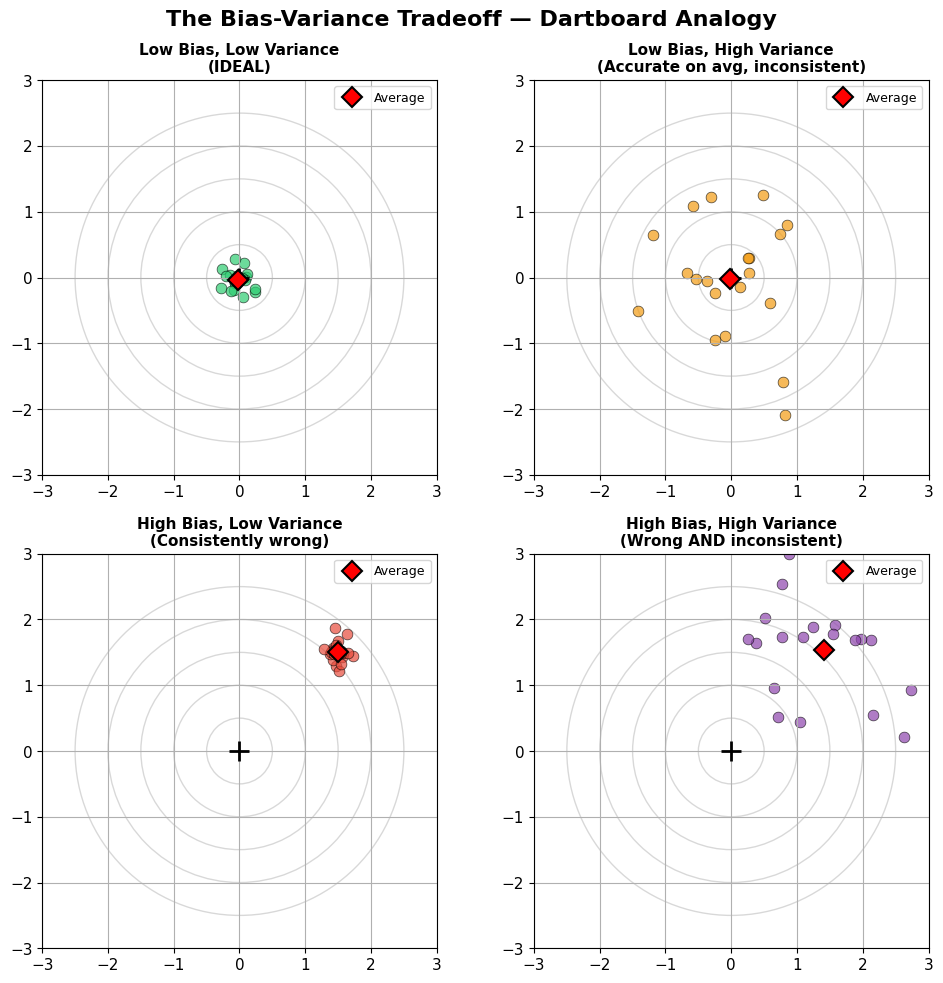

HOW TO READ THIS:
  + = bullseye (the TRUE answer)
  Colored dots = individual predictions (dart throws)
  Red diamond = average prediction

  Top-left:  Low bias + low variance = IDEAL (accurate + consistent)
  Top-right: Low bias + high variance = right on average, but unreliable
  Bot-left:  High bias + low variance = reliably wrong
  Bot-right: High bias + high variance = wrong AND unreliable


In [6]:
# ============================================================
# SECTION 2: The Dartboard Visualization
# ============================================================
# No ML yet — just dots on targets to build intuition.

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('The Bias-Variance Tradeoff — Dartboard Analogy', fontsize=16, fontweight='bold')

np.random.seed(42)
# Four scenarios = four quadrants of the bias-variance space. Build intuition before math.
scenarios = [
    ("Low Bias, Low Variance\n(IDEAL)", 0, 0, 0.15, '#2ecc71'),
    ("Low Bias, High Variance\n(Accurate on avg, inconsistent)", 0, 0, 0.8, '#f39c12'),
    ("High Bias, Low Variance\n(Consistently wrong)", 1.5, 1.5, 0.15, '#e74c3c'),
    ("High Bias, High Variance\n(Wrong AND inconsistent)", 1.5, 1.5, 0.8, '#8e44ad'),
]

# Each subplot = one bias-variance combination. Compare all four side-by-side.
for ax, (title, bx, by, spread, color) in zip(axes.flat, scenarios):
    # Concentric rings give visual reference for how far throws land from center
    for r in [2.5, 2.0, 1.5, 1.0, 0.5]:
        circle = plt.Circle((0, 0), r, fill=False, color='gray', alpha=0.3)
        ax.add_patch(circle)

    # Product A
    ax.plot(0, 0, 'k+', markersize=15, markeredgewidth=2)

    # Throws clustered near center = low bias + low variance = IDEAL
    throws_x = np.random.normal(bx, spread, 20)
    throws_y = np.random.normal(by, spread, 20)
    ax.scatter(throws_x, throws_y, c=color, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Red diamond shows the AVERAGE — bias is how far this average is from the bullseye
    ax.plot(np.mean(throws_x), np.mean(throws_y), 'D', color='red',
            markersize=10, markeredgecolor='black', markeredgewidth=1.5, label='Average')

    # Fixed axis range [-3,3] so all four subplots share the same scale for fair comparison
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("HOW TO READ THIS:")
print("  + = bullseye (the TRUE answer)")
print("  Colored dots = individual predictions (dart throws)")
print("  Red diamond = average prediction")
print()
print("  Top-left:  Low bias + low variance = IDEAL (accurate + consistent)")
print("  Top-right: Low bias + high variance = right on average, but unreliable")
print("  Bot-left:  High bias + low variance = reliably wrong")
print("  Bot-right: High bias + high variance = wrong AND unreliable")

### Connecting Darts to Models

| Dart Scenario | ML Model Equivalent | What Happens |
|--------------|-------------------|--------------|
| Low bias, low variance | Well-tuned model (right complexity) | Good train score, good test score |
| Low bias, high variance | Overfit model (too complex) | Great train score, bad test score |
| High bias, low variance | Underfit model (too simple) | Bad train score, bad test score |
| High bias, high variance | Wrong model entirely | Bad everything — start over |

Let's see this with real models. We'll fit polynomials of increasing degree to California Housing data and watch overfitting emerge.

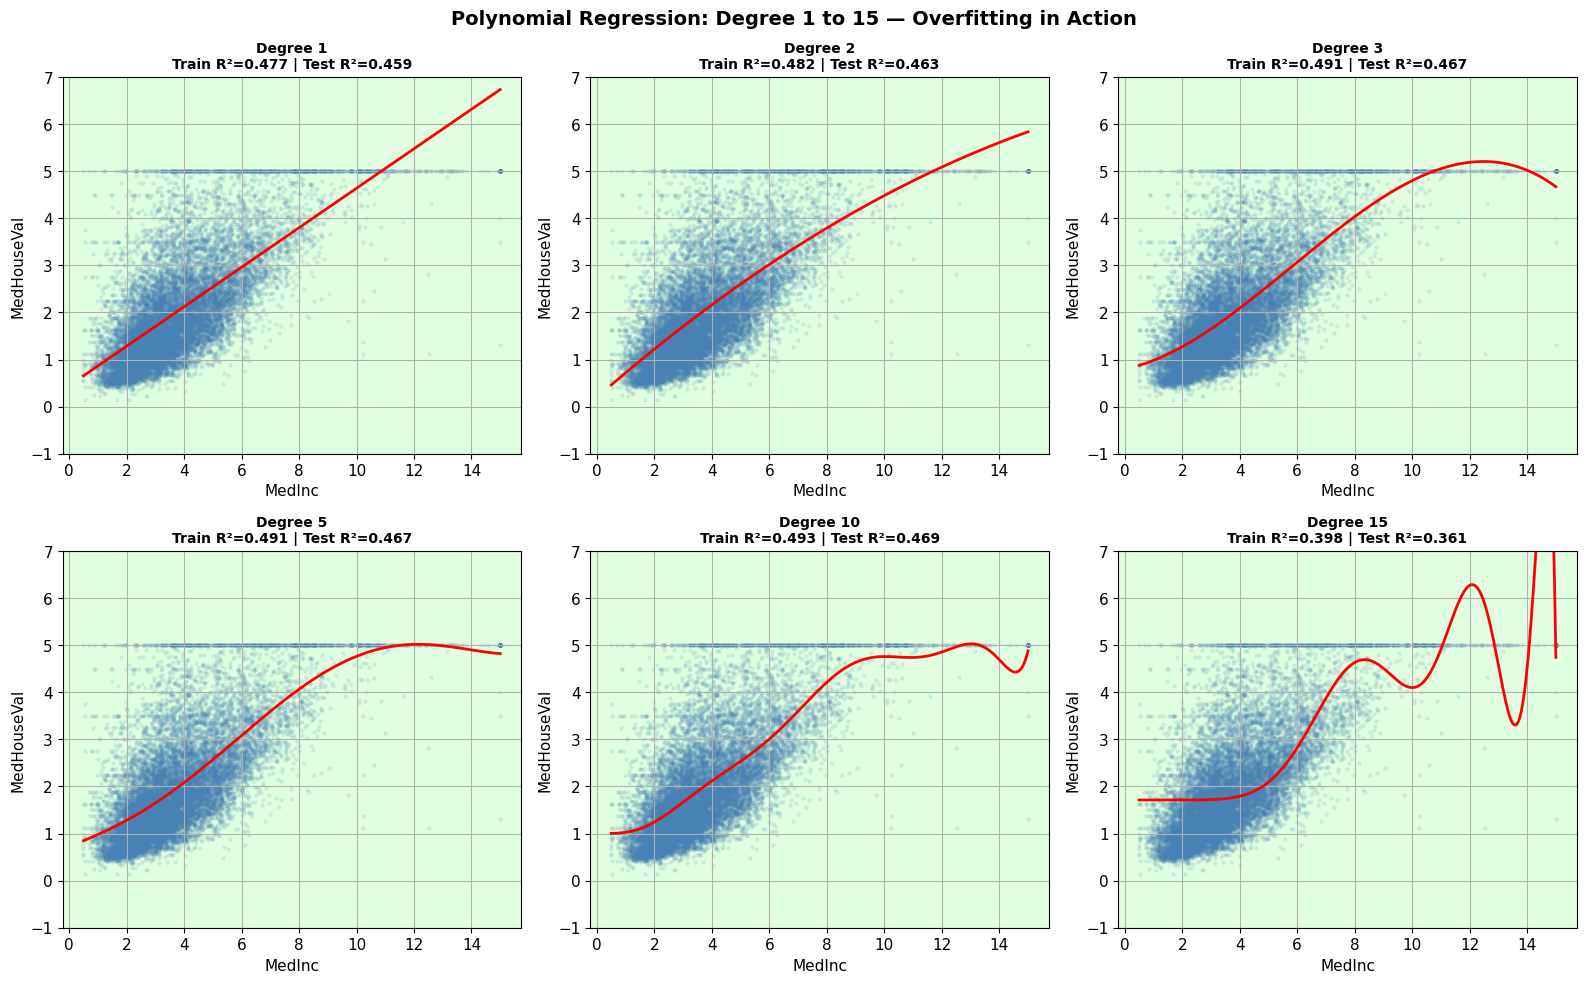

WHAT YOU SEE:
  Degree 1:  Straight line — too simple, misses the curve (UNDERFITTING)
  Degree 2-3: Captures the curve without going wild (GOOD)
  Degree 10+: Wild oscillations at the edges (OVERFITTING)

  Green background = test score close to train (good generalization)
  Red background   = train >> test (overfitting)


In [7]:
# ============================================================
# SECTION 2: Polynomial Regression — Watch Overfitting Emerge
# ============================================================
# We'll fit polynomials of degree 1 (straight line) through degree 15
# to a subset of California Housing data and see what happens.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Single feature (MedInc) so we can plot 2D — multi-feature overfitting is invisible
X_single = X_train_h[['MedInc']].values
y_single = y_train_h.values
X_single_test = X_test_h[['MedInc']].values
y_single_test = y_test_h.values

# Sort by MedInc for smooth curve plotting — scatter plots don't need this, line plots do
sort_idx = X_single.ravel().argsort()
X_sorted = X_single[sort_idx]
y_sorted = y_single[sort_idx]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Polynomial Regression: Degree 1 to 15 — Overfitting in Action',
             fontsize=14, fontweight='bold')

# Fit polynomials of increasing degree — watch the curve go from too rigid to too wiggly
degrees = [1, 2, 3, 5, 10, 15]
for ax, deg in zip(axes.flat, degrees):
    # Create polynomial features: degree 3 means [x, x², x³]. More terms = more flexibility.
    poly = PolynomialFeatures(deg, include_bias=False)
    X_poly = poly.fit_transform(X_sorted)
    X_poly_test = poly.transform(X_single_test)

    # Still LinearRegression — only the FEATURES changed (polynomial terms), not the algorithm
    model = LinearRegression()
    model.fit(X_poly, y_sorted)

    # Predict on a dense range for smooth curves — raw data is too sparse for clean lines
    X_range = np.linspace(X_sorted.min(), X_sorted.max(), 300).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range = model.predict(X_range_poly)

    # Scores
    train_r2 = model.score(X_poly, y_sorted)
    test_r2 = model.score(X_poly_test, y_single_test)

    # Plot
    ax.scatter(X_sorted, y_sorted, alpha=0.1, s=5, color='steelblue')
    ax.plot(X_range, y_range, color='red', linewidth=2)
    ax.set_title(f'Degree {deg}\nTrain R²={train_r2:.3f} | Test R²={test_r2:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')
    ax.set_ylim(-1, 7)

    # Color-code: green = generalizing, red = memorizing. Visual cue before reading numbers.
    gap = abs(train_r2 - test_r2)
    if gap > 0.1:
        ax.patch.set_facecolor('#ffe0e0')
    elif test_r2 > 0.3:
        ax.patch.set_facecolor('#e0ffe0')

plt.tight_layout()
plt.show()

print("WHAT YOU SEE:")
print("  Degree 1:  Straight line — too simple, misses the curve (UNDERFITTING)")
print("  Degree 2-3: Captures the curve without going wild (GOOD)")
print("  Degree 10+: Wild oscillations at the edges (OVERFITTING)")
print()
print("  Green background = test score close to train (good generalization)")
print("  Red background   = train >> test (overfitting)")

### The U-Shaped Error Curve

This is the signature diagram of the bias-variance tradeoff:
- **Training error** always drops as complexity increases (the model memorizes more)
- **Test error** drops, then RISES (the model starts memorizing noise instead of patterns)

The sweet spot — minimum test error — is where the tradeoff is optimally balanced.

### What Does "Degree" Mean in This Chart?

Degree = **how many bends you allow in the line.** It is a complexity dial.

We are predicting house price from **one feature: MedInc (Median Income)**. But we let the model create polynomial combinations of that feature:

| Degree | What the Model Can Draw | Analogy |
|:---|:---|:---|
| 1 | Straight line | "Higher income = higher price." Simple rule. |
| 2 | One curve (parabola) | "Price goes up with income, but levels off for very rich neighborhoods." |
| 3 | Two bends | Getting more specific. Captures real nuance. |
| 15 | 15 bends — a wild snake | The curve twists through every training point, including noise. It memorized the data. |

We picked 15 because it is high enough that the overfitting is obvious on the plot. The number itself is arbitrary — 10 or 20 would tell the same story. The point is: more bends = more flexibility = more memorization risk.

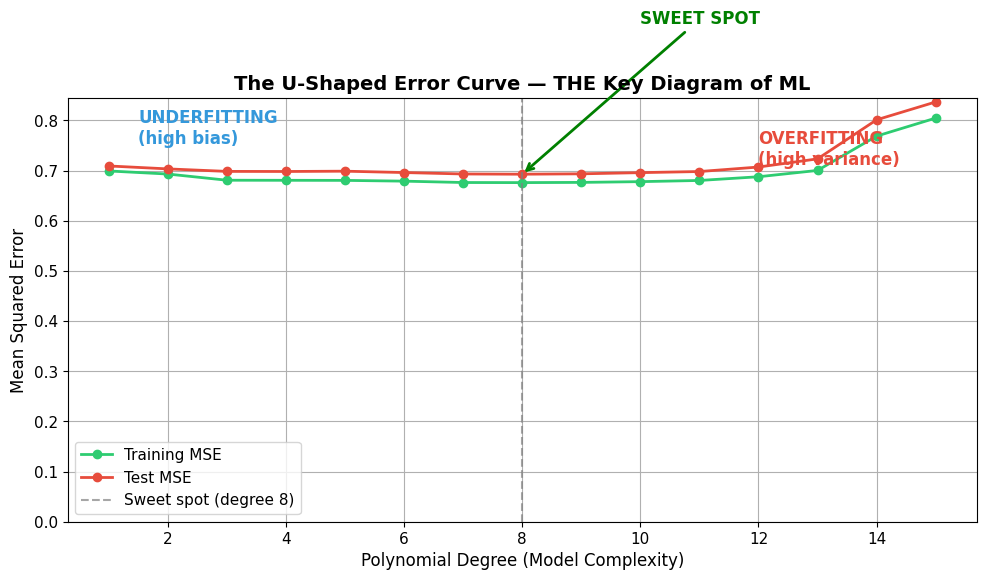

Best polynomial degree (lowest test error): 8

THE PATTERN (memorize this):
  - Training error ALWAYS decreases with more complexity
  - Test error decreases, then INCREASES
  - The gap between them is the OVERFITTING indicator
  - Your job: find the degree where TEST error is minimized


In [8]:
# ============================================================
# SECTION 2: The U-Shaped Error Curve
# ============================================================
# This is THE signature diagram of ML — train error always drops, test error drops then RISES
# Plot training MSE vs test MSE across polynomial degrees.
# The sweet spot is where test error is minimized.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 15 degrees = 15 models of increasing complexity. The U-curve emerges from this sweep.
degrees_range = range(1, 16)
train_mses = []
test_mses = []

# Training on increasingly complex polynomials — each degree adds flexibility to fit curves
for deg in degrees_range:
    poly = PolynomialFeatures(deg, include_bias=False)
    X_poly_train = poly.fit_transform(X_train_h[['MedInc']].values)
    X_poly_test = poly.transform(X_test_h[['MedInc']].values)

    model = LinearRegression()
    model.fit(X_poly_train, y_train_h.values)

    train_mses.append(mean_squared_error(y_train_h, model.predict(X_poly_train)))
    test_mses.append(mean_squared_error(y_test_h, model.predict(X_poly_test)))

# Minimum TEST error (not train!) identifies the sweet spot — train error is always misleading
best_deg = list(degrees_range)[np.argmin(test_mses)]

plt.figure(figsize=(10, 6))
# Green = train, red = test. The gap between them IS the overfitting measure.
plt.plot(list(degrees_range), train_mses, 'o-', label='Training MSE', linewidth=2, color='#2ecc71')
plt.plot(list(degrees_range), test_mses, 'o-', label='Test MSE', linewidth=2, color='#e74c3c')
# Vertical line marks the sweet spot — everything to the right is unnecessary complexity
plt.axvline(x=best_deg, color='gray', linestyle='--', alpha=0.7, label=f'Sweet spot (degree {best_deg})')

# Label the three zones: underfitting (left), sweet spot (middle), overfitting (right)
plt.annotate('UNDERFITTING\n(high bias)', xy=(1.5, max(test_mses)*0.9),
             fontsize=12, fontweight='bold', color='#3498db')
plt.annotate('OVERFITTING\n(high variance)', xy=(12, max(test_mses)*0.85),
             fontsize=12, fontweight='bold', color='#e74c3c')
plt.annotate('SWEET SPOT', xy=(best_deg, min(test_mses)),
             xytext=(best_deg+2, min(test_mses)+0.3),
             fontsize=12, fontweight='bold', color='green',
             arrowprops=dict(arrowstyle='->', color='green', lw=2))

plt.xlabel('Polynomial Degree (Model Complexity)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('The U-Shaped Error Curve — THE Key Diagram of ML', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f"Best polynomial degree (lowest test error): {best_deg}")
print()
print("THE PATTERN (memorize this):")
print("  - Training error ALWAYS decreases with more complexity")
print("  - Test error decreases, then INCREASES")
print("  - The gap between them is the OVERFITTING indicator")
print("  - Your job: find the degree where TEST error is minimized")

### Underfitting vs Overfitting vs Just Right

| | Underfitting | Just Right | Overfitting |
|---|---|---|---|
| **Bias** | High | Low | Low |
| **Variance** | Low | Moderate | High |
| **Train score** | Low | Good | Very high (suspiciously good) |
| **Test score** | Low | Good | Much lower than train |
| **Train-Test gap** | Small (both bad) | Small (both good) | LARGE |
| **Diagnosis** | "Model is too simple" | "Model generalizes" | "Model memorized the training data" |
| **Fix** | More features, more complex model | Ship it | Regularization, simpler model, more data |

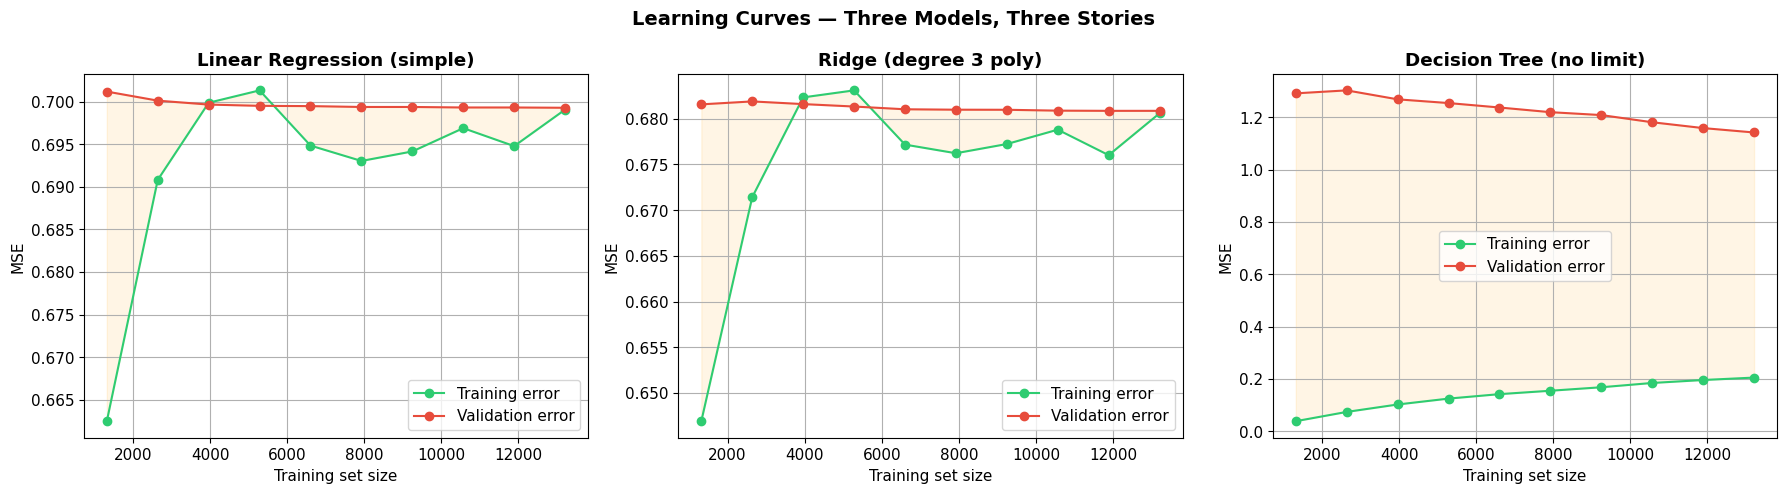

HOW TO READ LEARNING CURVES:

  Linear Regression: Both lines converge at HIGH error
    = UNDERFITTING. The model is too simple. More data won't help.
    Fix: use a more complex model.

  Ridge (degree 3): Lines converge at LOWER error
    = GOOD FIT. Adding polynomial features helped. Regularization prevents overfitting.

  Decision Tree (no limit): Big gap between train and test
    = OVERFITTING. Train error is near zero (memorized!), test error is high.
    Fix: limit tree depth, prune, or use regularization.


In [9]:
# ============================================================
# SECTION 2: Learning Curves — The Diagnostic Tool
# ============================================================
# Learning curves show how train/test scores change as you add more data.
# Three models = three stories. Learning curves show how MORE DATA affects each.

from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge

# 1x3 layout so all three learning curves are directly comparable side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Three models chosen to show three different stories: too simple, just right, too complex
models = [
    ("Linear Regression (simple)", LinearRegression()),
    ("Ridge (degree 3 poly)", Ridge(alpha=1.0)),
    ("Decision Tree (no limit)", DecisionTreeRegressor(random_state=42)),
]

for ax, (name, model) in zip(axes, models):
    # Ridge with degree-3 polynomial = regularized complexity. Best of both worlds.
    if 'Ridge' in name:
        from sklearn.pipeline import Pipeline
        model = Pipeline([
            ('poly', PolynomialFeatures(3, include_bias=False)),
            ('ridge', Ridge(alpha=1.0))
        ])

    # learning_curve trains on 10%, 20%, ... 100% of data. Shows if MORE DATA would help.
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_h[['MedInc']].values, y_train_h.values,
        train_sizes=np.linspace(0.1, 1.0, 10), cv=5,
        scoring='neg_mean_squared_error', n_jobs=-1
    )

    # Negate because sklearn returns neg_MSE (convention: higher = better for optimizers)
    train_mean = -train_scores.mean(axis=1)
    test_mean = -test_scores.mean(axis=1)

    # Green = train, Red = validation. Same color convention as U-curve for consistency.
    ax.plot(train_sizes, train_mean, 'o-', label='Training error', color='#2ecc71')
    ax.plot(train_sizes, test_mean, 'o-', label='Validation error', color='#e74c3c')
    # The gap between curves = overfitting signal. Smaller gap = better generalization.
    ax.fill_between(train_sizes, train_mean, test_mean, alpha=0.1, color='orange')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('MSE')
    ax.set_title(name, fontweight='bold')
    ax.legend()

plt.suptitle('Learning Curves — Three Models, Three Stories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("HOW TO READ LEARNING CURVES:")
print()
print("  Linear Regression: Both lines converge at HIGH error")
print("    = UNDERFITTING. The model is too simple. More data won't help.")
print("    Fix: use a more complex model.")
print()
print("  Ridge (degree 3): Lines converge at LOWER error")
print("    = GOOD FIT. Adding polynomial features helped. Regularization prevents overfitting.")
print()
print("  Decision Tree (no limit): Big gap between train and test")
print("    = OVERFITTING. Train error is near zero (memorized!), test error is high.")
print("    Fix: limit tree depth, prune, or use regularization.")

In [10]:
# ============================================================
# SECTION 2: Bias-Variance Summary — Quick Reference
# ============================================================
# Compact summary you can screenshot and keep on your desk.

# DataFrame format so students can screenshot or copy — this is the cheat sheet for Section 2
summary = pd.DataFrame({
    'Scenario': ['Underfitting', 'Good fit', 'Overfitting'],
    'Bias': ['High', 'Low', 'Low'],
    'Variance': ['Low', 'Moderate', 'High'],
    'Train Score': ['Low', 'Good', 'Very High'],
    'Test Score': ['Low', 'Good (close to train)', 'Much lower than train'],
    'Fix': ['More complex model', 'Ship it!', 'Regularize, simplify, more data'],
})

print("BIAS-VARIANCE QUICK REFERENCE")
print("=" * 90)
print(summary.to_string(index=False))
print()
print("DIAGNOSTIC SHORTCUT:")
print("  1. Compute train and test scores")
print("  2. If BOTH are low -> underfitting (bias problem)")
print("  3. If train is high but test is low -> overfitting (variance problem)")
print("  4. If both are high and close -> good fit")

BIAS-VARIANCE QUICK REFERENCE
    Scenario Bias Variance Train Score            Test Score                             Fix
Underfitting High      Low         Low                   Low              More complex model
    Good fit  Low Moderate        Good Good (close to train)                        Ship it!
 Overfitting  Low     High   Very High Much lower than train Regularize, simplify, more data

DIAGNOSTIC SHORTCUT:
  1. Compute train and test scores
  2. If BOTH are low -> underfitting (bias problem)
  3. If train is high but test is low -> overfitting (variance problem)
  4. If both are high and close -> good fit


> **Architect's Note:** Like premature optimization in software — a simple function that handles edge cases gracefully beats a clever one that breaks on unexpected input. Degree-2 polynomial is the `O(n)` solution that works. Degree-15 is the `O(1)` lookup table that only works for inputs it's seen before. When a model underperforms, the FIRST question: "Is this a bias problem or a variance problem?" The answer determines whether you need more complexity (bias) or more data/regularization (variance).

---

## 3. Overfitting vs Underfitting — Named and Diagnosed

Step1 Part 9 showed you what happens when Linear Regression encounters curved data (it underfits). Step1 Exercise 2 showed you learning curves. But we never **named** the problem systematically or gave you a **diagnostic toolkit**.

This section does both.

### What Step1 Already Showed You

- **Step1 Part 9:** Linear Regression on curved data — the line couldn't capture the curve. That was **underfitting**, but we didn't name it.
- **Step1 Exercise 2:** Learning curves showing train and test scores converging. The gap between them was the overfitting signal, but we didn't give you a systematic diagnostic.

Now we name the problem, build a reusable diagnostic tool, and give you a checklist.

In [11]:
# ============================================================
# SECTION 3: Decision Tree — Overfitting vs Constrained
# ============================================================
# Decision Trees are prone to overfitting because they can split until
# every training sample has its own leaf. Let's see it.

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Overfit tree — no constraints, will memorize training data
tree_overfit = DecisionTreeRegressor(random_state=42)
tree_overfit.fit(X_train_h, y_train_h)

# Constrained tree — max_depth=5 prevents going too deep
tree_constrained = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_constrained.fit(X_train_h, y_train_h)

# Compare
models_compare = {
    'Overfit Tree (no limit)': tree_overfit,
    'Constrained Tree (depth=5)': tree_constrained,
}

print(f"{'Model':<30} {'Train R²':>10} {'Test R²':>10} {'Gap':>10} {'Diagnosis':>15}")
print("-" * 80)
for name, m in models_compare.items():
    train_r2 = r2_score(y_train_h, m.predict(X_train_h))
    test_r2 = r2_score(y_test_h, m.predict(X_test_h))
    gap = train_r2 - test_r2
    diag = "OVERFITTING" if gap > 0.1 else "OK"
    print(f"{name:<30} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>10.4f} {diag:>15}")

print()
print("KEY OBSERVATION:")
print("  The unlimited tree gets R²=1.00 on training data — PERFECT score.")
print("  But on test data? Much lower. It memorized, it didn't learn.")
print("  The constrained tree sacrifices training perfection for better generalization.")

Model                            Train R²    Test R²        Gap       Diagnosis
--------------------------------------------------------------------------------
Overfit Tree (no limit)            1.0000     0.6187     0.3813     OVERFITTING
Constrained Tree (depth=5)         0.6377     0.5997     0.0379              OK

KEY OBSERVATION:
  The unlimited tree gets R²=1.00 on training data — PERFECT score.
  But on test data? Much lower. It memorized, it didn't learn.
  The constrained tree sacrifices training perfection for better generalization.


In [12]:
# ============================================================
# SECTION 3: Diagnostic Dashboard — Reusable Function
# ============================================================
# This function creates a 3-panel diagnostic for ANY regression model.
# We'll use it throughout the rest of the notebook.

def diagnostic_dashboard(model, X_train, y_train, X_test, y_test, title="Model"):
    '''3-panel diagnostic: actual vs predicted, residuals, learning curve.'''
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Diagnostic Dashboard: {title}', fontsize=14, fontweight='bold')

    # Panel 1: Points on the red line = perfect. Scatter = error magnitude and pattern.
    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Actual vs Predicted')
    axes[0].legend()

    # Panel 2: Patterns here (curves, funnels) reveal systematic model failures
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(y=0, color='red', linewidth=1)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual')
    axes[1].set_title('Residuals (should be random)')

    # Panel 3: Bell-shaped = random errors (good). Skewed = systematic bias (investigate).
    axes[2].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Error Distribution (should be bell-shaped)')

    # Compute both scores to report the gap — the gap IS the overfitting diagnostic
    r2_train = r2_score(y_train, model.predict(X_train))
    r2_test = r2_score(y_test, y_pred)

    plt.tight_layout()
    plt.show()

    print(f"  Train R²: {r2_train:.4f} | Test R²: {r2_test:.4f} | Gap: {r2_train - r2_test:.4f}")

print("Diagnostic dashboard defined. Use it on any regression model.")
print("diagnostic_dashboard(model, X_train, y_train, X_test, y_test, title)")

Diagnostic dashboard defined. Use it on any regression model.
diagnostic_dashboard(model, X_train, y_train, X_test, y_test, title)


OVERFIT TREE (no depth limit):


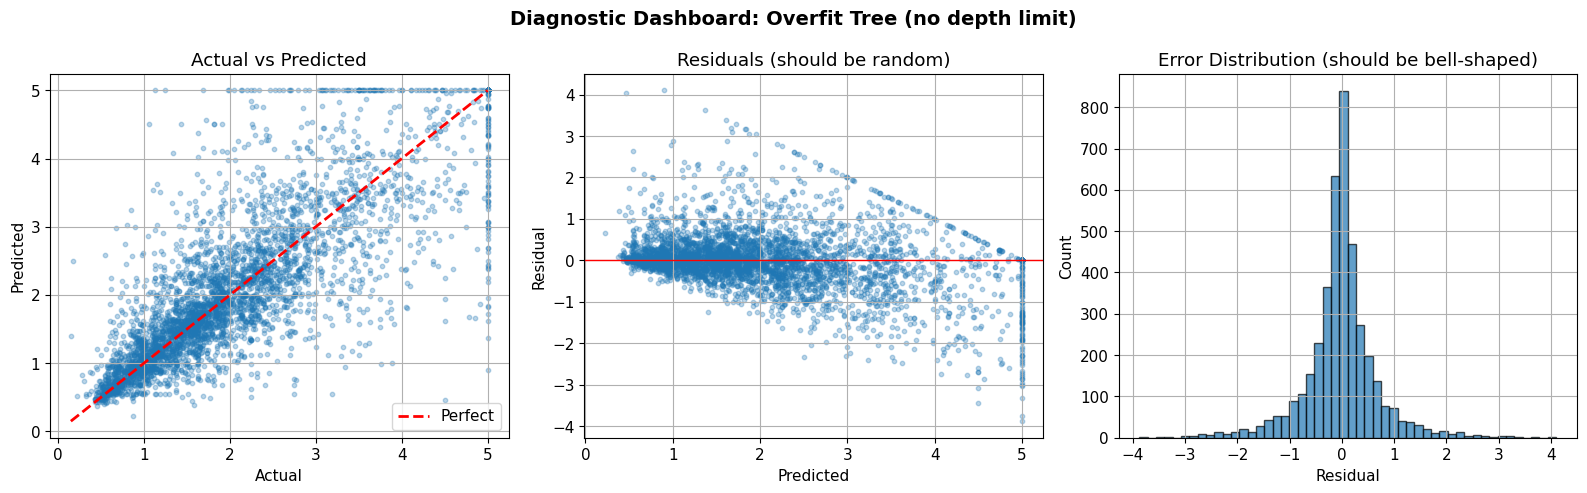

  Train R²: 1.0000 | Test R²: 0.6187 | Gap: 0.3813

CONSTRAINED TREE (max_depth=5):


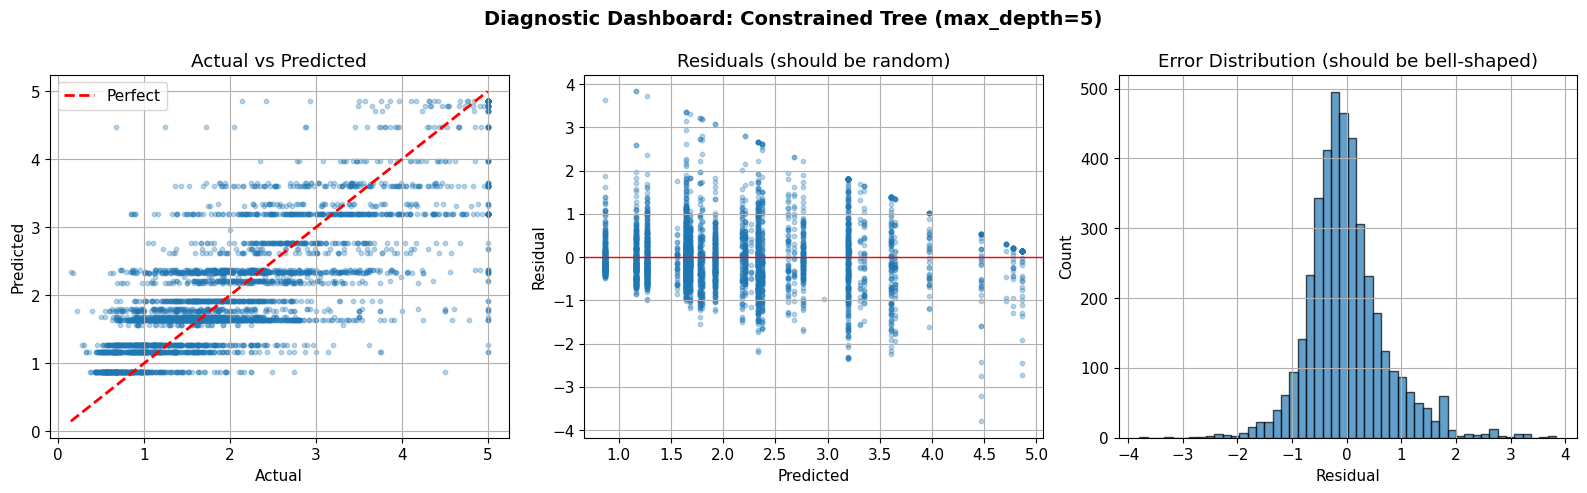

  Train R²: 0.6377 | Test R²: 0.5997 | Gap: 0.0379

COMPARE:
  Overfit tree: residuals might look random, but the train-test gap is huge
  Constrained tree: slightly worse fit, but the gap is much smaller


In [13]:
# ============================================================
# SECTION 3: Apply Dashboard to Both Trees
# ============================================================
# See the visual difference between an overfit and constrained model.

print("OVERFIT TREE (no depth limit):")
diagnostic_dashboard(tree_overfit, X_train_h, y_train_h, X_test_h, y_test_h,
                     "Overfit Tree (no depth limit)")
print()
print("CONSTRAINED TREE (max_depth=5):")
diagnostic_dashboard(tree_constrained, X_train_h, y_train_h, X_test_h, y_test_h,
                     "Constrained Tree (max_depth=5)")
print()
print("COMPARE:")
print("  Overfit tree: residuals might look random, but the train-test gap is huge")
print("  Constrained tree: slightly worse fit, but the gap is much smaller")

### Diagnostic Checklist

When your model underperforms, follow this checklist:

| Symptom | Diagnosis | Fix |
|---------|-----------|-----|
| Train score low, test score low, small gap | **Underfitting** (high bias) | More features, more complex model, less regularization |
| Train score high, test score low, large gap | **Overfitting** (high variance) | Regularization, simpler model, more data, dropout |
| Train score high, test score high, small gap | **Good fit** | Ship it |
| Patterned residuals (curves, funnel shape) | **Wrong model type** | Try non-linear model, add polynomial features |
| Skewed error distribution | **Systematic bias** | Check for data issues, feature engineering |

> **Architect's Note:** The train-test gap is your single most important diagnostic.
> A gap > 10% of the train score usually signals overfitting.

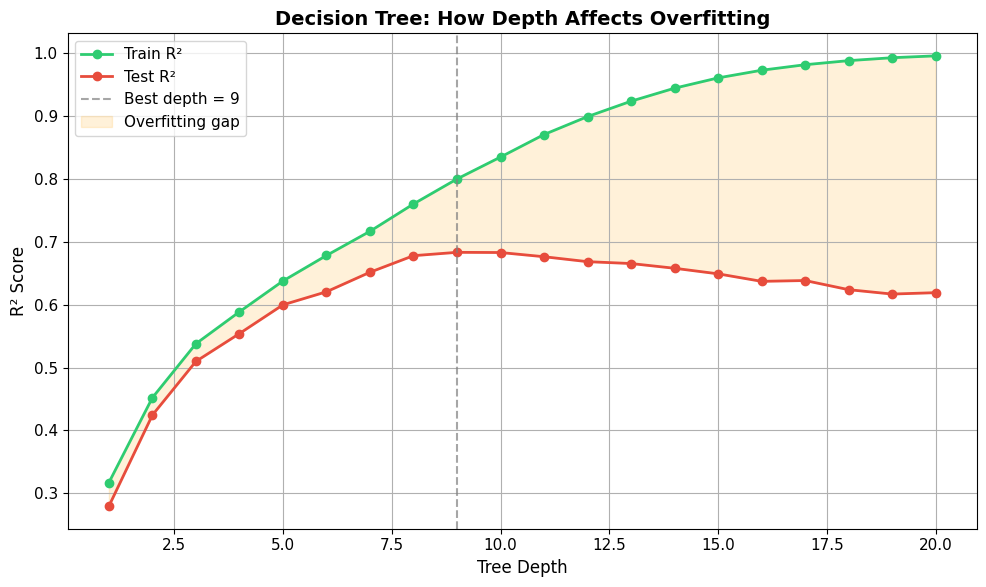

Best depth (highest test R²): 9
Test R² at best depth: 0.6833

PATTERN:
  - Train R² keeps climbing (the tree memorizes more)
  - Test R² peaks around depth 9, then plateaus or drops
  - The orange gap = overfitting
  - max_depth is a HYPERPARAMETER — Section 6 automates finding the best value


In [14]:
# ============================================================
# SECTION 3: Train-Test Gap vs Tree Depth
# ============================================================
# Sweep tree depth from 1 to 20 and plot the divergence point.

depths = range(1, 21)
train_r2s = []
test_r2s = []

# Sweep max_depth from 1-20 to find where the tree starts memorizing instead of learning
for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train_h, y_train_h)
    train_r2s.append(r2_score(y_train_h, tree.predict(X_train_h)))
    test_r2s.append(r2_score(y_test_h, tree.predict(X_test_h)))

# Peak test R² identifies the optimal depth — going deeper only helps the training score
best_depth = list(depths)[np.argmax(test_r2s)]

plt.figure(figsize=(10, 6))
# Same green/red convention — train always looks better, test reveals the truth
plt.plot(list(depths), train_r2s, 'o-', label='Train R²', color='#2ecc71', linewidth=2)
plt.plot(list(depths), test_r2s, 'o-', label='Test R²', color='#e74c3c', linewidth=2)
plt.axvline(x=best_depth, color='gray', linestyle='--', alpha=0.7,
            label=f'Best depth = {best_depth}')
# Orange gap = the overfitting region. Wider gap = more memorization, less generalization.
plt.fill_between(list(depths), train_r2s, test_r2s, alpha=0.15, color='orange',
                 label='Overfitting gap')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Decision Tree: How Depth Affects Overfitting', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
# This is WHY max_depth is a hyperparameter — Section 6 automates finding the optimal value

print(f"Best depth (highest test R²): {best_depth}")
print(f"Test R² at best depth: {test_r2s[best_depth-1]:.4f}")
print()
print("PATTERN:")
print("  - Train R² keeps climbing (the tree memorizes more)")
print("  - Test R² peaks around depth {}, then plateaus or drops".format(best_depth))
print("  - The orange gap = overfitting")
print("  - max_depth is a HYPERPARAMETER — Section 6 automates finding the best value")

---

## 4. Regularization — A Tax on Complexity

Overfitting happens when a model's weights get too large — it contorts itself to fit every training point. Regularization is the fix: **add a penalty for large weights to the loss function.**

### The Analogy

Think of it as a tax on complexity:
- Without regularization: the model can use any size weights, free of charge
- With regularization: every unit of weight "costs" something
- The model has to justify each weight — "is this feature worth the penalty?"

This forces the model to keep weights small, which makes it smoother and less likely to overfit.

In [15]:
# ============================================================
# SECTION 4: Hello World — Regularization in 5 Lines
# ============================================================
# Ridge regression = Linear regression + L2 penalty. One parameter added.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Scale features — REQUIRED for regularization.
# Without scaling, MedInc (range 0-15) gets penalized differently
# than Population (range 0-35000), not because it matters less,
# but because its NUMBERS are smaller. Scaling fixes this.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_h)
X_test_scaled = scaler.transform(X_test_h)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_h)
print(f"Ridge R²: {ridge.score(X_test_scaled, y_test_h):.4f}")
print()
print("That's regularization. One parameter (alpha) added to LinearRegression.")
print("Now let's understand what it actually did to the weights.")

Ridge R²: 0.5758

That's regularization. One parameter (alpha) added to LinearRegression.
Now let's understand what it actually did to the weights.


### Why Does Regularization Work?

Step by step:

1. **Normal loss** = minimize prediction errors (make ŷ close to y)
2. **Regularized loss** = minimize errors **+ keep weights small**
3. The optimizer now has **TWO competing goals**
4. Large weights mean the model is "trying too hard" to fit every training point — including noise
5. The penalty forces the model to find a SIMPLER solution that still predicts well

**The math (you don't need to memorize this, just understand the shape):**
- Normal: Loss = Σ(y - ŷ)²
- Ridge:  Loss = Σ(y - ŷ)² + α × Σ(weights²)
- Lasso:  Loss = Σ(y - ŷ)² + α × Σ|weights|

The α (alpha) parameter controls the tax rate. Higher α = heavier tax = simpler model.

### L1 vs L2 vs ElasticNet

| | L1 (Lasso) | L2 (Ridge) | ElasticNet |
|---|---|---|---|
| **Penalty** | Sum of \|weights\| | Sum of weights² | Both |
| **Effect on weights** | Sets some to EXACTLY zero | Shrinks all toward zero | Both |
| **Feature selection?** | YES — zeros out irrelevant features | No — keeps all features | Partial |
| **Math** | Loss + α × ‖w‖₁ | Loss + α × ‖w‖₂² | Loss + α × [l1_ratio × ‖w‖₁ + (1-l1_ratio) × ‖w‖₂²] |
| **When to use** | Many features, some irrelevant | All features useful | Not sure which |
| **sklearn class** | `Lasso` | `Ridge` | `ElasticNet` |

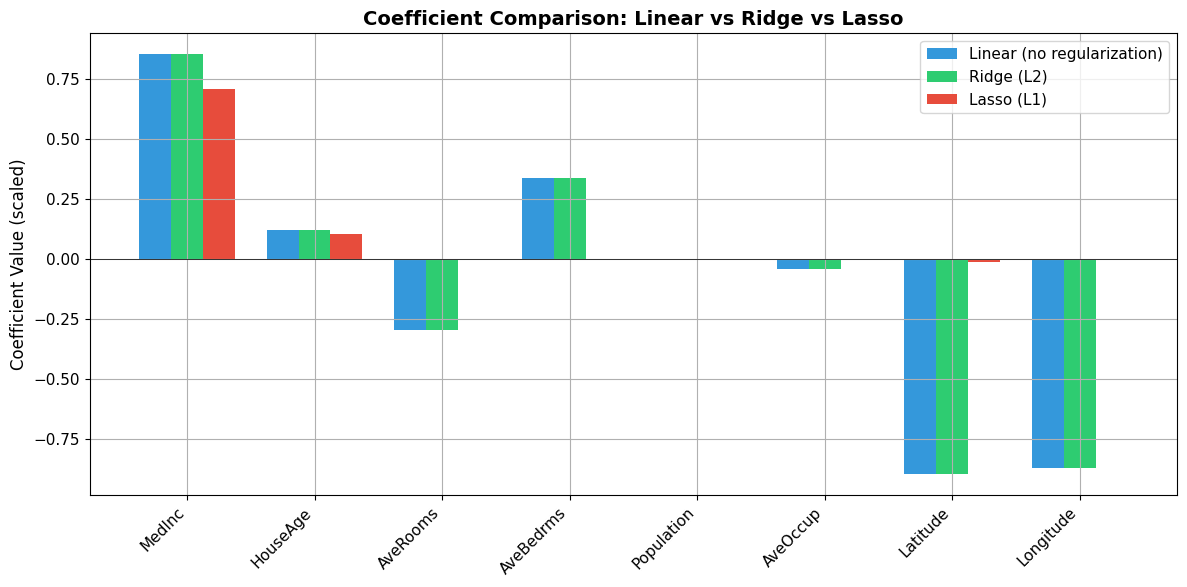

WHAT YOU SEE:
  Blue (Linear): No constraints — coefficients can be any size
  Green (Ridge): ALL coefficients shrunk toward zero, but none eliminated
  Red (Lasso):   Some coefficients pushed to EXACTLY zero (feature selection!)

  Lasso eliminated: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
  These features are not useful enough to justify the penalty.


In [16]:
# ============================================================
# SECTION 4: Ridge vs Lasso — Coefficient Comparison
# ============================================================
# Ridge shrinks ALL coefficients. Lasso zeros out some entirely.
# Let's see the difference on California Housing.
# (X_train_scaled and X_test_scaled already created in the hello world above)

from sklearn.linear_model import Lasso

# Same data, different penalties — differences in coefficients reveal what regularization does
lr = LinearRegression().fit(X_train_scaled, y_train_h)
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train_h)
lasso = Lasso(alpha=0.1).fit(X_train_scaled, y_train_h)

# Compare coefficients — this is WHERE you see regularization's effect
coef_df = pd.DataFrame({
    'Feature': X_train_h.columns,
    'Linear': lr.coef_,
    'Ridge (alpha=1)': ridge.coef_,
    'Lasso (alpha=0.1)': lasso.coef_,
})

# Side-by-side bars let you compare the SAME feature across three penalty levels
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(coef_df))
width = 0.25

ax.bar(x - width, coef_df['Linear'], width, label='Linear (no regularization)', color='#3498db')
ax.bar(x, coef_df['Ridge (alpha=1)'], width, label='Ridge (L2)', color='#2ecc71')
ax.bar(x + width, coef_df['Lasso (alpha=0.1)'], width, label='Lasso (L1)', color='#e74c3c')

ax.set_xticks(x)
# Rotated labels prevent overlap — 8 feature names don't fit horizontally
ax.set_xticklabels(coef_df['Feature'], rotation=45, ha='right')
ax.set_ylabel('Coefficient Value (scaled)', fontsize=12)
ax.set_title('Coefficient Comparison: Linear vs Ridge vs Lasso', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("WHAT YOU SEE:")
print("  Blue (Linear): No constraints — coefficients can be any size")
print("  Green (Ridge): ALL coefficients shrunk toward zero, but none eliminated")
print("  Red (Lasso):   Some coefficients pushed to EXACTLY zero (feature selection!)")
print()
# Lasso's zero coefficients = automatic feature selection. This is WHY you'd choose L1 over L2.
zeroed = coef_df[coef_df['Lasso (alpha=0.1)'].abs() < 0.001]['Feature'].tolist()
if zeroed:
    print(f"  Lasso eliminated: {zeroed}")
    print("  These features are not useful enough to justify the penalty.")
else:
    print("  All features survived Lasso (all are useful enough).")

In [17]:
# ============================================================
# SECTION 4: Deliberate Mistake — What Happens at the Extremes?
# ============================================================
# alpha=0 means NO penalty (plain linear regression).
# alpha=10000 means EXTREME penalty (all coefficients crushed to near zero).
# Both extremes are bad — but for different reasons.

from sklearn.metrics import r2_score

# Three alphas spanning 8 orders of magnitude — deliberately extreme to expose failure modes
extreme_alphas = [0.0001, 1.0, 10000]
print(f"{'Alpha':>10}  {'Test R²':>8}  {'Max |coef|':>12}  {'What happened':>30}")
print("-" * 70)

for a in extreme_alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train_h)
    r2 = r2_score(y_test_h, r.predict(X_test_scaled))
    max_coef = np.max(np.abs(r.coef_))
    if a < 0.01:
        note = "No penalty → overfitting risk"
    elif a > 1000:
        note = "Extreme penalty → predicts the mean"
    else:
        note = "Balanced → best generalization"
    print(f"{a:>10.4f}  {r2:>8.4f}  {max_coef:>12.4f}  {note:>30}")

print()
print("See? alpha=0.0001 is effectively no regularization.")
print("alpha=10000 crushes every coefficient — the model just predicts the average.")
print("Both extremes are bad. The sweet spot is in the middle.")

     Alpha   Test R²    Max |coef|                   What happened
----------------------------------------------------------------------
    0.0001    0.5758        0.8969   No penalty → overfitting risk
    1.0000    0.5758        0.8962  Balanced → best generalization
10000.0000    0.4472        0.4880  Extreme penalty → predicts the mean

See? alpha=0.0001 is effectively no regularization.
alpha=10000 crushes every coefficient — the model just predicts the average.
Both extremes are bad. The sweet spot is in the middle.


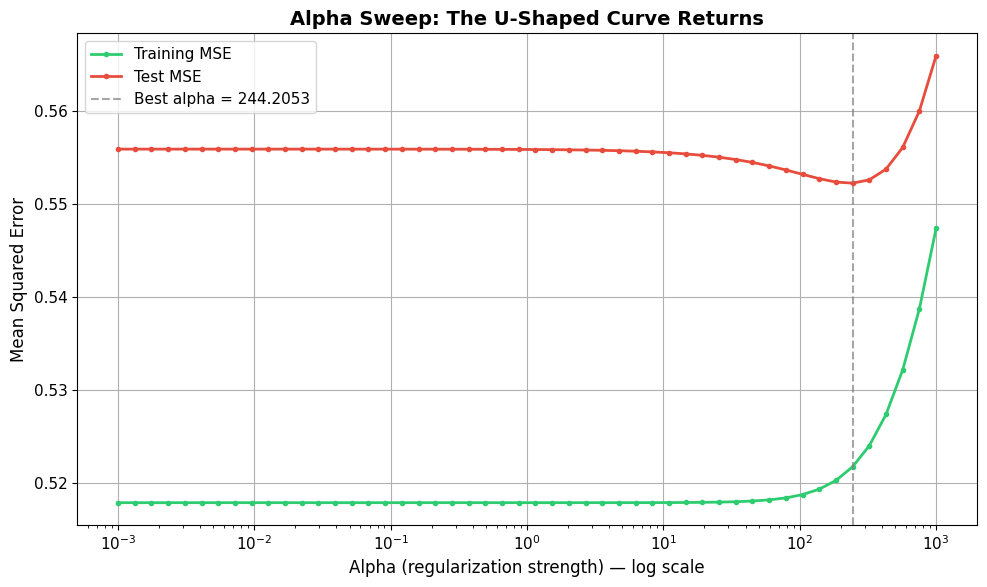

Best alpha: 244.2053

SAME PATTERN as polynomial degree:
  Too low alpha (left)  = too little regularization = overfitting
  Too high alpha (right) = too much regularization = underfitting
  Sweet spot in the middle

Section 6 automates this search with GridSearchCV.


In [18]:
# ============================================================
# SECTION 4: Alpha Sweep — The U-Shaped Error Curve Returns
# ============================================================
# alpha = sklearn's name for λ (lambda). Controls the "tax rate" on weights.
# Low alpha = low tax = model can use large weights = overfitting risk
# High alpha = high tax = model forced to use small weights = underfitting risk
# The U-shaped curve appears again — same tradeoff, different knob.

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Log-spaced alphas cover 6 orders of magnitude — linear spacing would miss the sweet spot
alphas = np.logspace(-3, 3, 50)  # 0.001 to 1000
train_errors = []
test_errors = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_h)
    train_errors.append(mean_squared_error(y_train_h, ridge.predict(X_train_scaled)))
    test_errors.append(mean_squared_error(y_test_h, ridge.predict(X_test_scaled)))

# argmin on TEST errors, not train — same principle as polynomial degree selection
best_alpha_idx = np.argmin(test_errors)
best_alpha = alphas[best_alpha_idx]

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, train_errors, 'o-', label='Training MSE', color='#2ecc71', linewidth=2, markersize=3)
plt.semilogx(alphas, test_errors, 'o-', label='Test MSE', color='#e74c3c', linewidth=2, markersize=3)
plt.axvline(x=best_alpha, color='gray', linestyle='--', alpha=0.7,
            label=f'Best alpha = {best_alpha:.4f}')
plt.xlabel('Alpha (regularization strength) — log scale', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Alpha Sweep: The U-Shaped Curve Returns', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Best alpha: {best_alpha:.4f}")
print()
print("SAME PATTERN as polynomial degree:")
print("  Too low alpha (left)  = too little regularization = overfitting")
print("  Too high alpha (right) = too much regularization = underfitting")
print("  Sweet spot in the middle")
print()
print("Section 6 automates this search with GridSearchCV.")

In [19]:
# ============================================================
# SECTION 4: Ridge vs Lasso — R² Score Comparison
# ============================================================
# Coefficients show WHAT changed. Now let's see if it MATTERS for predictions.

from sklearn.linear_model import Lasso

# All three models trained on SAME scaled data — isolates the regularization effect
models_reg = {
    'LinearRegression (no penalty)': LinearRegression().fit(X_train_scaled, y_train_h),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0).fit(X_train_scaled, y_train_h),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1).fit(X_train_scaled, y_train_h),
}

# The gap column reveals overfitting — smaller gap = better generalization

print(f"{'Model':<35} {'Train R²':>10} {'Test R²':>10} {'Gap':>10}")
print("-" * 70)
for name, m in models_reg.items():
    tr = r2_score(y_train_h, m.predict(X_train_scaled))
    te = r2_score(y_test_h, m.predict(X_test_scaled))
    print(f"{name:<35} {tr:>10.4f} {te:>10.4f} {tr-te:>10.4f}")

print()
print("On this dataset, regularization has minimal impact because:")
print("  1. The dataset is large (16K+ samples) — overfitting is less of a risk")
print("  2. All features are somewhat useful — Lasso doesn't gain much by zeroing them")
print("  3. The real limitation is model TYPE (linear), not regularization")
print()
print("Regularization matters MOST with: small datasets, many features, or high-degree polynomials.")

Model                                 Train R²    Test R²        Gap
----------------------------------------------------------------------
LinearRegression (no penalty)           0.6126     0.5758     0.0368
Ridge (alpha=1.0)                       0.6126     0.5758     0.0367
Lasso (alpha=0.1)                       0.4974     0.4814     0.0161

On this dataset, regularization has minimal impact because:
  1. The dataset is large (16K+ samples) — overfitting is less of a risk
  2. All features are somewhat useful — Lasso doesn't gain much by zeroing them
  3. The real limitation is model TYPE (linear), not regularization

Regularization matters MOST with: small datasets, many features, or high-degree polynomials.


### Which Regularization to Use?

```
START HERE
    |
    v
Do you have many features, and suspect some are irrelevant?
    |           |
   YES          NO
    |           |
    v           v
  LASSO       Are all features potentially useful?
  (L1)            |           |
                 YES          NOT SURE
                  |           |
                  v           v
               RIDGE      ELASTICNET
               (L2)        (L1 + L2)
```

### Dropout — Regularization for Neural Networks (Preview)

In the Deep Learning section (Deep Learning), you'll learn **dropout** — regularization for neural networks. Same concept as L1/L2, different mechanism:

- **L1/L2:** Add a penalty to the loss function
- **Dropout:** Randomly "turn off" neurons during each training step

Why dropout works: if any single neuron can be randomly disabled, the network can't rely on any one path. It's forced to distribute the learned pattern across multiple neurons — making it more robust.

You don't need to understand dropout now. Just know it exists and serves the same purpose as L1/L2: **prevent overfitting by penalizing complexity.**

> **Architect's Note:** Like code review — you CAN write a 500-line function that handles every edge case inline. Regularization is the reviewer saying "simplify this or justify the complexity." The penalty forces you to earn every coefficient, the way a good code review forces you to earn every line. Start with Ridge (L2) unless you have a reason to use Lasso.

In [20]:
# ============================================================
# SECTION 4: ElasticNet — Varying l1_ratio
# ============================================================
# ElasticNet combines L1 and L2. The l1_ratio controls the mix:
#   l1_ratio=0 → pure Ridge (L2)
#   l1_ratio=1 → pure Lasso (L1)
#   0 < l1_ratio < 1 → mix of both

from sklearn.linear_model import ElasticNet

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for ratio in l1_ratios:
    en = ElasticNet(alpha=0.1, l1_ratio=ratio, random_state=42)
    en.fit(X_train_scaled, y_train_h)
    test_r2 = r2_score(y_test_h, en.predict(X_test_scaled))
    n_zero = np.sum(np.abs(en.coef_) < 0.001)
    results.append((ratio, test_r2, n_zero))

print(f"{'l1_ratio':>10} {'Test R²':>10} {'Features zeroed':>16} {'Behavior':>20}")
print("-" * 60)
for ratio, r2, nz in results:
    behavior = "More Ridge-like" if ratio < 0.5 else "More Lasso-like"
    print(f"{ratio:>10.1f} {r2:>10.4f} {nz:>16} {behavior:>20}")

print()
print("As l1_ratio increases (more L1), more features get zeroed out.")
print("Use ElasticNet when you want SOME feature selection but not as aggressive as pure Lasso.")

  l1_ratio    Test R²  Features zeroed             Behavior
------------------------------------------------------------
       0.1     0.5490                1      More Ridge-like
       0.3     0.5336                3      More Ridge-like
       0.5     0.5148                4      More Lasso-like
       0.7     0.4897                5      More Lasso-like
       0.9     0.4845                5      More Lasso-like

As l1_ratio increases (more L1), more features get zeroed out.
Use ElasticNet when you want SOME feature selection but not as aggressive as pure Lasso.


In [21]:
# ============================================================
# SECTION 4: Regularization on Classification
# ============================================================
# Regularization isn't just for regression. LogisticRegression uses it too.
# In fact, sklearn's LogisticRegression applies L2 regularization by DEFAULT.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Fit models with different penalties
log_l1 = LogisticRegression(penalty='l1', solver='saga', C=1.0,
                             max_iter=5000, random_state=42)
log_l2 = LogisticRegression(penalty='l2', C=1.0,
                             max_iter=5000, random_state=42)

# Scale classification data
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

log_l1.fit(X_train_c_scaled, y_train_c)
log_l2.fit(X_train_c_scaled, y_train_c)

print("Logistic Regression on Breast Cancer dataset:")
print(f"  L1 (Lasso): Accuracy = {accuracy_score(y_test_c, log_l1.predict(X_test_c_scaled)):.4f}")
print(f"  L2 (Ridge): Accuracy = {accuracy_score(y_test_c, log_l2.predict(X_test_c_scaled)):.4f}")
print()
print(f"  L1 features zeroed: {np.sum(np.abs(log_l1.coef_) < 0.001)}/{X_train_c.shape[1]}")
print(f"  L2 features zeroed: {np.sum(np.abs(log_l2.coef_) < 0.001)}/{X_train_c.shape[1]}")
print()
print("NOTE: In LogisticRegression, sklearn uses 'C' instead of 'alpha'.")
print("  C = 1/alpha. So C=0.01 means STRONG regularization (alpha=100).")
print("  This is a quirk of the sklearn API — be aware of it.")

Logistic Regression on Breast Cancer dataset:
  L1 (Lasso): Accuracy = 0.9649
  L2 (Ridge): Accuracy = 0.9737

  L1 features zeroed: 15/30
  L2 features zeroed: 0/30

NOTE: In LogisticRegression, sklearn uses 'C' instead of 'alpha'.
  C = 1/alpha. So C=0.01 means STRONG regularization (alpha=100).
  This is a quirk of the sklearn API — be aware of it.


In [22]:
# ============================================================
# SECTION 4: Exercise — Find the Best Alpha Manually
# ============================================================
# Try different alpha values for Ridge on California Housing.
# "Section 6 automates this with GridSearchCV."

print("EXERCISE: Find the best alpha for Ridge regression.")
print()
print("Try these alphas and note the test R²:")
print("  alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]")
print()

# Solution
alphas_manual = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
print(f"{'Alpha':>10} {'Train R²':>10} {'Test R²':>10}")
print("-" * 35)
for a in alphas_manual:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train_h)
    tr = r2_score(y_train_h, ridge.predict(X_train_scaled))
    te = r2_score(y_test_h, ridge.predict(X_test_scaled))
    print(f"{a:>10.3f} {tr:>10.4f} {te:>10.4f}")

print()
print("This manual search works, but it's tedious and only tests 6 values.")
print("GridSearchCV (Section 6) does this systematically with cross-validation.")

EXERCISE: Find the best alpha for Ridge regression.

Try these alphas and note the test R²:
  alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

     Alpha   Train R²    Test R²
-----------------------------------
     0.001     0.6126     0.5758
     0.010     0.6126     0.5758
     0.100     0.6126     0.5758
     1.000     0.6126     0.5758
    10.000     0.6125     0.5761
   100.000     0.6120     0.5778

This manual search works, but it's tedious and only tests 6 values.
GridSearchCV (Section 6) does this systematically with cross-validation.


---

## 5. Feature Engineering — Better Features Beat Complex Models

Feature engineering is the art of creating better model inputs from raw data. It's where **domain knowledge meets ML**.

A well-engineered feature can improve a simple model more than switching to a complex algorithm. This is why senior ML engineers spend 80% of their time on data and features, and only 20% on models.

**What Step1 already covered:**
- Step1 Part 7: Feature importance (coefficient analysis)
- Step1 Part 8: Feature scaling (StandardScaler, data leakage trap)

**What's new here:**
- Systematic feature selection (statistical tests)
- Encoding categorical variables (one-hot, label, ordinal)
- Handling missing values (imputation strategies)
- Dealing with imbalanced classes (the accuracy trap from Step2 Part 5)

### The Principle

> "Better features > complex model. Domain knowledge meets ML."

A senior ML engineer at Google shared this rule of thumb: 80% of ML project time goes into data and features, 20% into modeling. Getting the right features into the model matters more than choosing the fanciest algorithm. Let's prove it.

In [23]:
# ============================================================
# SECTION 5: Hello World — One Feature Changes Everything
# ============================================================
# Train Ridge on raw features, then add ONE engineered feature.
# Watch the R² improve. No algorithm change. Just better data.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# BEFORE: raw features only
scaler_fe = StandardScaler()
X_raw_train = scaler_fe.fit_transform(X_train_h)
X_raw_test = scaler_fe.transform(X_test_h)
ridge_raw = Ridge(alpha=1.0).fit(X_raw_train, y_train_h)
r2_before = r2_score(y_test_h, ridge_raw.predict(X_raw_test))

# AFTER: add ONE engineered feature — rooms per household
X_train_eng = X_train_h.copy()
X_test_eng = X_test_h.copy()
X_train_eng['RoomsPerHousehold'] = X_train_eng['AveRooms'] / X_train_eng['AveOccup'].clip(lower=1)
X_test_eng['RoomsPerHousehold'] = X_test_eng['AveRooms'] / X_test_eng['AveOccup'].clip(lower=1)

scaler_fe2 = StandardScaler()
X_eng_train = scaler_fe2.fit_transform(X_train_eng)
X_eng_test = scaler_fe2.transform(X_test_eng)
ridge_eng = Ridge(alpha=1.0).fit(X_eng_train, y_train_h)
r2_after = r2_score(y_test_h, ridge_eng.predict(X_eng_test))

print(f"BEFORE (raw features):          R² = {r2_before:.4f}")
print(f"AFTER  (+RoomsPerHousehold):     R² = {r2_after:.4f}")
print(f"Improvement:                     +{r2_after - r2_before:.4f}")
print()
print("One engineered feature improved the model. No algorithm change.")
print("That's why feature engineering is the first 50%.")

BEFORE (raw features):          R² = 0.5758
AFTER  (+RoomsPerHousehold):     R² = 0.6438
Improvement:                     +0.0680

One engineered feature improved the model. No algorithm change.
That's why feature engineering is the first 50%.


### Why Did That Work?

Raw `AveRooms` counts total rooms in the census block, not per household. A block with 1000 rooms could have 50 households (20 rooms each — mansions) or 500 households (2 rooms each — studios).

`RoomsPerHousehold` captures the actual living quality. The model couldn't learn this relationship from the raw numbers because it's a **ratio** — and linear models don't automatically discover ratios between features.

This is the essence of feature engineering: **encode domain knowledge into the data** so the model doesn't have to discover it from scratch.

In [24]:
# ============================================================
# SECTION 5: EDA — Explore the Data First
# ============================================================
# Before engineering features, LOOK at the data.

print("California Housing — Quick EDA")
print("=" * 50)
print()
print(X_housing.describe().round(2))
print()
print("Target (MedHouseVal) statistics:")
print(y_housing.describe().round(2))

California Housing — Quick EDA

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std        2.14       2.00  
min       32.54    -124.35  
25%       33.93    -121.80  
50%       34.26    -118.49  
75%       37.71    -118.01  
max       41.95    -114.31  

Target (MedHouseVal) statistics:
count    20640.00
mean  

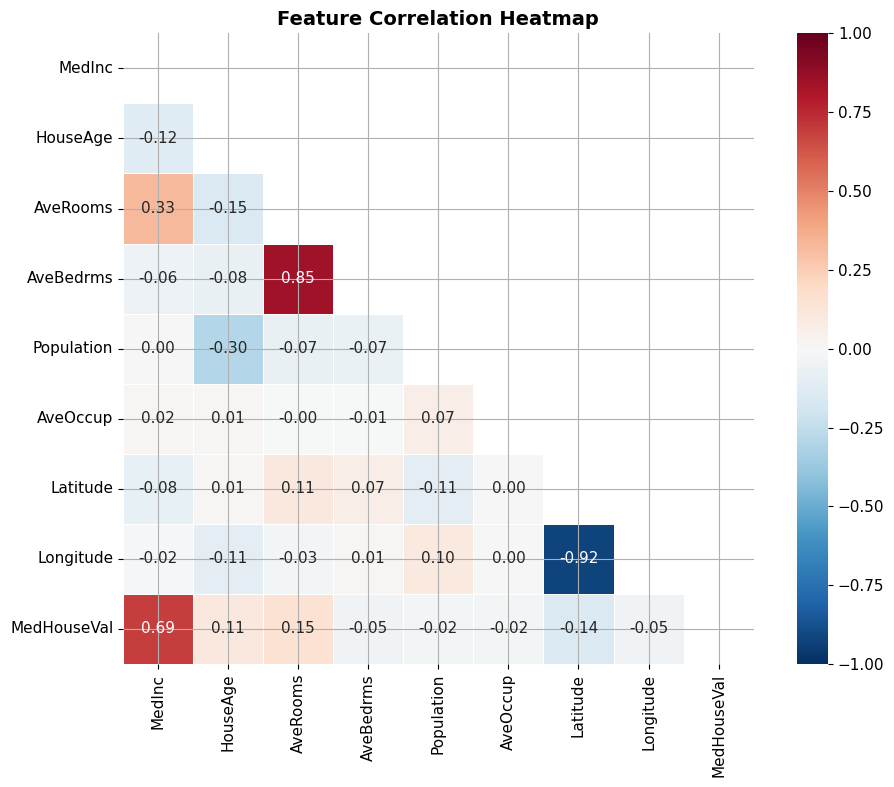

WHAT TO LOOK FOR:
  1. Correlation with target (bottom row): MedInc has strongest correlation
  2. Feature-feature correlation: AveRooms and AveBedrms are correlated
     (multicollinearity — Ridge handles this, Lasso eliminates one)


In [25]:
# ============================================================
# SECTION 5: Correlation Heatmap
# ============================================================
# Correlation tells you which features move together with the target.
# This was introduced in Step1 Exercise 1 — now we do it systematically.

full_df = X_housing.copy()
full_df['MedHouseVal'] = y_housing

plt.figure(figsize=(10, 8))
corr = full_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("WHAT TO LOOK FOR:")
print("  1. Correlation with target (bottom row): MedInc has strongest correlation")
print("  2. Feature-feature correlation: AveRooms and AveBedrms are correlated")
print("     (multicollinearity — Ridge handles this, Lasso eliminates one)")

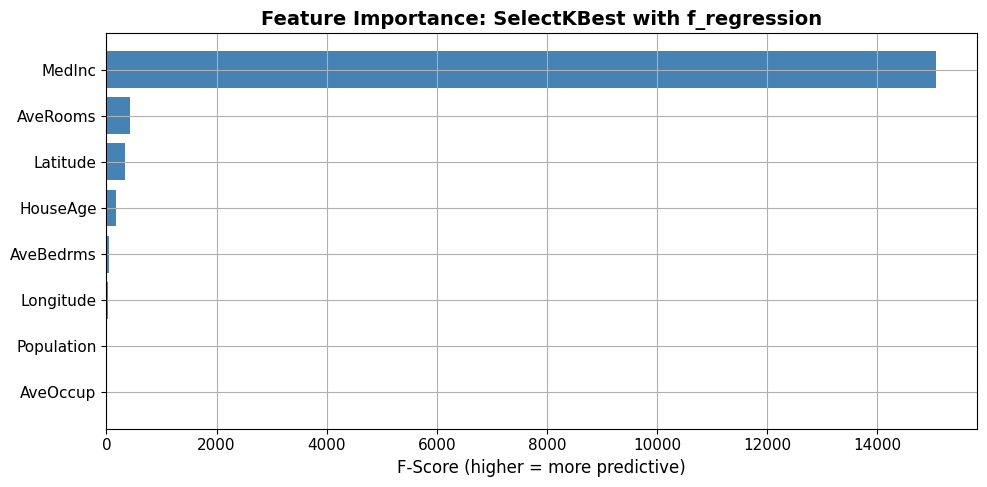

Feature ranking (highest F-score = most predictive):
  MedInc          F=   15057.4  ***
  AveRooms        F=     425.4  ***
  Latitude        F=     344.6  ***
  HouseAge        F=     179.5  ***
  AveBedrms       F=      43.7  ***
  Longitude       F=      35.5  ***
  Population      F=      11.2  ***
  AveOccup        F=       8.0  

NOTE: This confirms what Step1 Exercise 1 showed:
  MedInc dominates. But SelectKBest is a SYSTEMATIC approach
  that works with any dataset, not just ones you can eyeball.


In [26]:
# ============================================================
# SECTION 5: SelectKBest — Statistical Feature Ranking
# ============================================================
# Instead of eyeballing correlations, use a statistical test to
# rank features by their relationship with the target.

from sklearn.feature_selection import SelectKBest, f_regression

# Score each feature
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train_h, y_train_h)

# Results
feat_scores = pd.DataFrame({
    'Feature': X_train_h.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_,
}).sort_values('F-Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feat_scores['Feature'], feat_scores['F-Score'], color='steelblue')
ax.set_xlabel('F-Score (higher = more predictive)', fontsize=12)
ax.set_title('Feature Importance: SelectKBest with f_regression', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature ranking (highest F-score = most predictive):")
for _, row in feat_scores.iterrows():
    sig = "***" if row['p-value'] < 0.001 else ""
    print(f"  {row['Feature']:<15} F={row['F-Score']:>10.1f}  {sig}")

print()
print("NOTE: This confirms what Step1 Exercise 1 showed:")
print("  MedInc dominates. But SelectKBest is a SYSTEMATIC approach")
print("  that works with any dataset, not just ones you can eyeball.")

### Encoding Categorical Variables

Real-world data often has text categories (color, city, department). ML models need numbers. Three encoding strategies:

| Method | How It Works | When to Use | Sklearn |
|--------|-------------|------------|---------|
| **One-Hot** | Create binary column per category | Nominal (no order): color, city | `OneHotEncoder` |
| **Label** | Map to integers: red=0, blue=1, green=2 | Only for tree-based models (they handle arbitrary splits) | `LabelEncoder` |
| **Ordinal** | Map to ordered integers: low=0, medium=1, high=2 | Ordinal (has natural order): education level | `OrdinalEncoder` |

In [27]:
# ============================================================
# SECTION 5: Encoding Demo — One-Hot, Label, Ordinal
# ============================================================

# ML models require numeric inputs — encoding bridges the gap from text categories to numbers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

# Synthetic data isolates the encoding concept — no noise from real-world messiness
cat_data = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue', 'green', 'red', 'blue'],
    'size': ['small', 'medium', 'large', 'small', 'large', 'medium', 'large', 'small'],
    'price': [10, 20, 30, 12, 35, 22, 28, 18]
})

print("Original data:")
print(cat_data)
print()

# One-Hot avoids implying order — red=0, blue=1 would tell the model blue > red
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' avoids redundancy
encoded = ohe.fit_transform(cat_data[['color', 'size']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out())
print("One-Hot Encoded (drop='first' to avoid dummy variable trap):")
print(encoded_df)
print()

# Ordinal preserves the natural order — the model CAN learn that large > medium > small
oe = OrdinalEncoder(categories=[['small', 'medium', 'large']])
cat_data['size_ordinal'] = oe.fit_transform(cat_data[['size']])
print("Ordinal Encoded (size: small=0, medium=1, large=2):")
print(cat_data[['size', 'size_ordinal']])
print()
print("RULE OF THUMB:")
print("  No natural order (red/blue/green) -> One-Hot encoding")
print("  Natural order (small/medium/large) -> Ordinal encoding")
print("  Tree models can handle Label encoding (splits on arbitrary thresholds)")

Original data:
   color    size  price
0    red   small     10
1   blue  medium     20
2  green   large     30
3    red   small     12
4   blue   large     35
5  green  medium     22
6    red   large     28
7   blue   small     18

One-Hot Encoded (drop='first' to avoid dummy variable trap):
   color_green  color_red  size_medium  size_small
0          0.0        1.0          0.0         1.0
1          0.0        0.0          1.0         0.0
2          1.0        0.0          0.0         0.0
3          0.0        1.0          0.0         1.0
4          0.0        0.0          0.0         0.0
5          1.0        0.0          1.0         0.0
6          0.0        1.0          0.0         0.0
7          0.0        0.0          0.0         1.0

Ordinal Encoded (size: small=0, medium=1, large=2):
     size  size_ordinal
0   small           0.0
1  medium           1.0
2   large           2.0
3   small           0.0
4   large           2.0
5  medium           1.0
6   large           2.0
7  

### Handling Missing Values

Real data is messy. Missing values are everywhere. Strategy depends on how much is missing and why:

| Strategy | When to Use | Sklearn |
|----------|------------|---------|
| **Drop rows** | <5% missing, randomly missing | `DataFrame.dropna()` |
| **Mean/Median imputation** | Numerical, not too many missing | `SimpleImputer(strategy='mean')` |
| **Mode imputation** | Categorical features | `SimpleImputer(strategy='most_frequent')` |
| **KNN (K-Nearest Neighbors) imputation** | Features are correlated | `KNNImputer(n_neighbors=5)` |
| **Flag + impute** | Missingness itself is informative | Add `is_missing` column + impute |

In [28]:
# ============================================================
# SECTION 5: Handling Missing Values — Imputation Strategies
# ============================================================
# California Housing has no missing values. Let's inject some
# to practice imputation strategies.

from sklearn.impute import SimpleImputer, KNNImputer

# Inject missingness randomly — simulates real-world data quality issues
np.random.seed(42)
X_missing = X_train_h.copy()
mask = np.random.random(len(X_missing)) < 0.10
X_missing.loc[mask, 'MedInc'] = np.nan
print(f"Injected {mask.sum()} missing values into MedInc ({mask.mean()*100:.1f}%)")
print()

# Dropping rows = losing information. Only acceptable when <5% is missing.
X_dropped = X_missing.dropna()
print(f"Strategy 1 — Drop rows: {len(X_missing)} -> {len(X_dropped)} rows ({len(X_missing)-len(X_dropped)} lost)")

# Mean is the simplest fill — replaces unknowns with the column average
mean_imp = SimpleImputer(strategy='mean')
X_mean = pd.DataFrame(mean_imp.fit_transform(X_missing),
                       columns=X_missing.columns, index=X_missing.index)
print(f"Strategy 2 — Mean imputation: filled with {X_train_h['MedInc'].mean():.2f} (column mean)")

# Median resists outliers — a few millionaires won't skew the fill value
median_imp = SimpleImputer(strategy='median')
X_median = pd.DataFrame(median_imp.fit_transform(X_missing),
                         columns=X_missing.columns, index=X_missing.index)
print(f"Strategy 3 — Median imputation: filled with {X_train_h['MedInc'].median():.2f} (column median)")

# KNN uses nearby rows to estimate — leverages correlations between features
knn_imp = KNNImputer(n_neighbors=5)
X_knn = pd.DataFrame(knn_imp.fit_transform(X_missing),
                      columns=X_missing.columns, index=X_missing.index)
print(f"Strategy 4 — KNN imputation: filled with average of 5 nearest neighbors")

# Compare strategies: mean fills with average, median is robust to outliers
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

strategies = {
    'Drop rows': X_dropped,
    'Mean': X_mean,
    'Median': X_median,
    'KNN': X_knn,
}

print()
print(f"{'Strategy':<15} {'Train R²':>10} {'Test R²':>10}")
print("-" * 35)
# Train the SAME model with each imputed dataset — differences reveal imputation impact
for name, X_imp in strategies.items():
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_imp)
    y_tr = y_train_h.loc[X_imp.index]  # match rows for drop strategy
    X_te = sc.transform(X_test_h)
    ridge = Ridge(alpha=1.0).fit(X_tr, y_tr)
    train_r2 = r2_score(y_tr, ridge.predict(X_tr))
    test_r2 = r2_score(y_test_h, ridge.predict(X_te))
    print(f"{name:<15} {train_r2:>10.4f} {test_r2:>10.4f}")

print()
print("With only 10% missing in one feature, strategies perform similarly.")
print("KNN shines when missingness is correlated with other features.")

Injected 1699 missing values into MedInc (10.3%)

Strategy 1 — Drop rows: 16512 -> 14813 rows (1699 lost)
Strategy 2 — Mean imputation: filled with 3.88 (column mean)
Strategy 3 — Median imputation: filled with 3.55 (column median)


Strategy 4 — KNN imputation: filled with average of 5 nearest neighbors

Strategy          Train R²    Test R²
-----------------------------------
Drop rows           0.6131     0.5765
Mean                0.5648     0.5811
Median              0.5642     0.5810
KNN                 0.5625     0.5811

With only 10% missing in one feature, strategies perform similarly.
KNN shines when missingness is correlated with other features.


### Dealing with Imbalanced Classes

The **accuracy trap** from Step2 Part 5: if 95% of samples are class A, a model that always predicts A gets 95% accuracy but is completely useless.

Real-world imbalance examples:
- Fraud detection: 99.9% legitimate, 0.1% fraud
- Medical diagnosis: 99% healthy, 1% disease
- Manufacturing: 98% good parts, 2% defective

Three strategies:
1. **Class weights** — tell the model to penalize minority class errors more
2. **Resampling** — oversample minority or undersample majority
3. **Better metrics** — use precision, recall, F1 instead of accuracy

### Evaluation Metrics in Plain English — Precision, Recall, F1, and ROC-AUC

Accuracy alone is dangerous. If 80% of bank customers do NOT churn, a model that predicts "no churn" every single time gets 80% accuracy — and catches zero actual churners. Completely useless.

You need metrics that answer different questions:

**The Hospital Analogy:**

Imagine a cancer screening test. 1,000 patients. 10 actually have cancer. 990 are healthy.

| Metric | Question It Answers | Hospital Example |
|:---|:---|:---|
| **Accuracy** | Of all patients tested, how many did we classify correctly? | 985/1,000 = 98.5% (sounds great, but misses the point) |
| **Precision** | Of everyone we flagged as "cancer," how many actually have cancer? | We flagged 15 patients. 8 actually have cancer, 7 are false alarms. Precision = 8/15 = 53%. |
| **Recall** | Of everyone who actually has cancer, how many did we catch? | 10 patients have cancer. We caught 8, missed 2. Recall = 8/10 = 80%. |
| **F1 Score** | Harmonic mean of precision and recall. One number that balances both. | F1 = 2 * (0.53 * 0.80) / (0.53 + 0.80) = 0.64 |

**Why "harmonic mean" instead of regular average?** The harmonic mean punishes imbalance. If precision is 99% but recall is 1%, a regular average says 50% (looks OK). The harmonic mean says 2% (correctly flags the problem).

### Which Metric Matters Most? It Depends on the Business.

| Use Case | Priority Metric | Why |
|:---|:---|:---|
| **Cancer screening** | **Recall** | Missing a cancer case can be fatal. False alarms just mean extra tests. |
| **Spam filter** | **Precision** | Sending a real email to spam loses business. Missing some spam is annoying but not catastrophic. |
| **Customer churn prediction** | **Recall** | Missing a churner costs you a customer. A false alarm just triggers a retention call — cheap. |
| **Fraud detection** | **Recall** (primarily) + monitor precision | Missing fraud loses money. But too many false alarms overwhelm the fraud team. |
| **Balanced problem (50/50 classes)** | **F1** or **ROC-AUC** | Neither class is more important. You want balanced performance. |

### ROC-AUC — The "Does the Model Actually Know the Difference?" Metric

**ROC-AUC (Receiver Operating Characteristic — Area Under Curve)** answers a deeper question: across ALL possible decision thresholds, how well does the model separate the two classes?

**The analogy:** Imagine sorting a deck of red and black cards by "how red they look." A perfect sort puts all reds on one side, all blacks on the other. A random sort mixes them evenly.

- **AUC = 1.0** — perfect separation. The model always ranks a real churner above a non-churner.
- **AUC = 0.5** — random guessing. The model cannot tell churners from non-churners.
- **AUC = 0.85** — good. 85% of the time, the model correctly ranks a churner higher than a non-churner.

**Why ROC-AUC over accuracy?**
- Accuracy depends on the threshold you choose ("predict churn if probability > 50%"). Change the threshold, accuracy changes.
- ROC-AUC evaluates ALL thresholds at once. It tells you if the model has learned the pattern, regardless of where you draw the line.

> **Explain Like I'm a CEO:** "Accuracy tells you how often the model is right. Recall tells you how many real problems it catches. Precision tells you how many of its alarms are real. ROC-AUC tells you whether the model actually understands the difference between the two groups. For our churn problem, we optimize for recall — catching churners — because losing a customer costs more than making a phone call to a false alarm."

In [29]:
# ============================================================
# SECTION 5: Imbalanced Classes — The Accuracy Trap
# ============================================================
# Create a deliberately imbalanced dataset and show why accuracy lies.

# classification_report shows per-class metrics — accuracy alone hides the problem
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a 95/5 split — simulates fraud detection, rare disease diagnosis, spam filtering
X_imb, y_imb = make_classification(n_samples=1000, n_features=20,
                                    weights=[0.95, 0.05], random_state=42)

# Stratified split preserves the 95/5 ratio in both train and test sets
from sklearn.model_selection import train_test_split
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42)

print(f"Class distribution: {np.bincount(y_tr_imb)}")
print(f"  Class 0: {(y_tr_imb==0).sum()} ({(y_tr_imb==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_tr_imb==1).sum()} ({(y_tr_imb==1).mean()*100:.1f}%)")
print()

# Default model treats both classes equally — optimizes overall accuracy, ignores minority
lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_default.fit(X_tr_imb, y_tr_imb)
y_pred_default = lr_default.predict(X_te_imb)

# class_weight='balanced' increases the penalty for misclassifying the minority class
lr_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_balanced.fit(X_tr_imb, y_tr_imb)
y_pred_balanced = lr_balanced.predict(X_te_imb)

print("DEFAULT (no class weight):")
print(f"  Accuracy: {accuracy_score(y_te_imb, y_pred_default):.4f}")
print(f"  Class 1 recall: {(y_pred_default[y_te_imb==1]==1).mean():.4f}")
print()
print("BALANCED (class_weight='balanced'):")
print(f"  Accuracy: {accuracy_score(y_te_imb, y_pred_balanced):.4f}")
print(f"  Class 1 recall: {(y_pred_balanced[y_te_imb==1]==1).mean():.4f}")
print()
print("Accuracy went DOWN but recall went UP.")
print("For fraud/disease detection, catching the minority class matters more than accuracy.")

Class distribution: [758  42]
  Class 0: 758 (94.8%)
  Class 1: 42 (5.2%)

DEFAULT (no class weight):
  Accuracy: 0.9350
  Class 1 recall: 0.0909

BALANCED (class_weight='balanced'):
  Accuracy: 0.8350
  Class 1 recall: 0.5455

Accuracy went DOWN but recall went UP.
For fraud/disease detection, catching the minority class matters more than accuracy.


In [30]:
# ============================================================
# SECTION 5: classification_report — The Right Metrics
# ============================================================
# For the breast cancer dataset (real-world medical diagnosis).

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# max_iter=10000 because convergence warnings distract from the metrics lesson
lr_cancer = LogisticRegression(max_iter=10000, random_state=42)
lr_cancer.fit(X_train_c, y_train_c)
# predict() gives class labels (0/1). predict_proba() gives probabilities — used for ROC curves.
y_pred_cancer = lr_cancer.predict(X_test_c)

print("Breast Cancer — Classification Report")
print("=" * 55)
print(classification_report(y_test_c, y_pred_cancer,
                            target_names=['Malignant', 'Benign']))
print()
print("KEY METRICS:")
print("  Precision: of all predicted positive, how many ARE positive?")
print("  Recall:    of all actual positive, how many did we FIND?")
print("  F1:        harmonic mean of precision and recall")
print()
print("For cancer detection, recall for Malignant matters most —")
print("missing a cancer (false negative) is worse than a false alarm.")

Breast Cancer — Classification Report
              precision    recall  f1-score   support

   Malignant       0.97      0.91      0.94        43
      Benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


KEY METRICS:
  Precision: of all predicted positive, how many ARE positive?
  Recall:    of all actual positive, how many did we FIND?
  F1:        harmonic mean of precision and recall

For cancer detection, recall for Malignant matters most —
missing a cancer (false negative) is worse than a false alarm.


> **Architect's Note:** Like choosing the right data structure. ArrayList vs HashMap don't change your algorithm — but the right choice makes it 100x faster. Features are the data structures of ML. `RoomsPerHousehold` is the HashMap that makes the model's job trivial. Raw `AveRooms` is the ArrayList that forces the model to do extra work on every lookup.

---

## 6. Hyperparameter Tuning — The Last 5% of Performance

Parameters are learned FROM data (weights, coefficients). Hyperparameters are set BEFORE training (learning rate, tree depth, regularization strength).

| Term | Set By | Example |
|------|--------|---------|
| **Parameter** | The model learns it | Linear regression coefficients, tree split thresholds |
| **Hyperparameter** | You choose it | `alpha` in Ridge, `max_depth` in DecisionTree, `n_estimators` in RandomForest |

How do you find the best hyperparameters? You could guess. Or you could search systematically.

In [31]:
# ============================================================
# SECTION 6: GridSearchCV — Exhaustive Search
# ============================================================
# Try EVERY combination of hyperparameters using cross-validation.
# This is the brute-force approach — reliable but slow.

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Define the parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

# GridSearchCV: try all alphas, evaluate each with 5-fold CV
grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True
)
grid_search.fit(X_train_scaled, y_train_h)

print("GridSearchCV Results")
print("=" * 50)
print(f"Best alpha: {grid_search.best_params_['alpha']}")
print(f"Best CV MSE: {-grid_search.best_score_:.4f}")
print()

# Show all results
results = pd.DataFrame(grid_search.cv_results_)
for _, row in results.iterrows():
    print(f"  alpha={row['param_alpha']:<8}  "
          f"CV MSE={-row['mean_test_score']:.4f} "
          f"(+/- {row['std_test_score']:.4f})")

GridSearchCV Results
Best alpha: 0.1
Best CV MSE: 0.5193

  alpha=0.001     CV MSE=0.5193 (+/- 0.0149)
  alpha=0.01      CV MSE=0.5193 (+/- 0.0149)
  alpha=0.1       CV MSE=0.5193 (+/- 0.0149)
  alpha=1.0       CV MSE=0.5193 (+/- 0.0149)
  alpha=10.0      CV MSE=0.5193 (+/- 0.0148)
  alpha=100.0     CV MSE=0.5204 (+/- 0.0143)


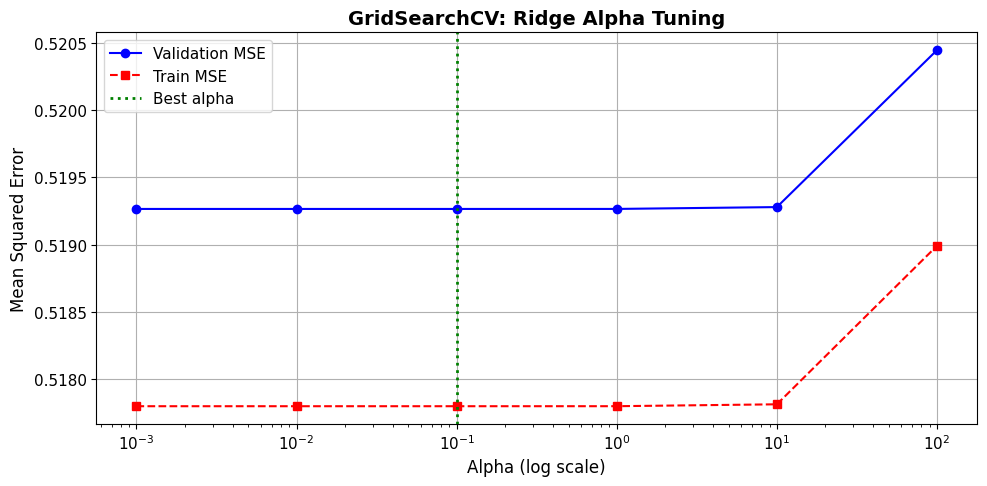

LEFT of best: underfitting (too much regularization)
RIGHT of best: overfitting (too little regularization)
Best alpha balances bias and variance.


In [32]:
# ============================================================
# SECTION 6: Visualize GridSearch Results
# ============================================================

# cv_results_ contains per-fold scores — richer than just best_score_
results = pd.DataFrame(grid_search.cv_results_)

# Log scale on x-axis — alphas span orders of magnitude, linear would squash the left side
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(results['param_alpha'].astype(float),
            -results['mean_test_score'], 'bo-', label='Validation MSE')
ax.semilogx(results['param_alpha'].astype(float),
            -results['mean_train_score'], 'rs--', label='Train MSE')

# Best alpha = lowest validation MSE. Mark it so the visual answer is immediate.
best_idx = results['mean_test_score'].idxmax()
ax.axvline(x=float(results.loc[best_idx, 'param_alpha']),
           color='green', linestyle=':', linewidth=2, label='Best alpha')

ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('GridSearchCV: Ridge Alpha Tuning', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("LEFT of best: underfitting (too much regularization)")
print("RIGHT of best: overfitting (too little regularization)")
print("Best alpha balances bias and variance.")

In [33]:
# ============================================================
# SECTION 6: Deliberate Mistake — What If You Tune on Test Data?
# ============================================================
# Why use cross-validation instead of just testing every alpha on the test set?
# Let's try the WRONG way first, then the right way.

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# WRONG WAY: using test data to select hyperparameters contaminates the final evaluation
alphas_wrong = np.logspace(-3, 3, 50)
best_test_r2 = -1
best_alpha_wrong = None

# Each iteration peeks at test data — by the end, we've optimized FOR this specific test set
for alpha in alphas_wrong:
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train_h)
    test_r2 = r2_score(y_test_h, ridge.predict(X_test_scaled))
    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        best_alpha_wrong = alpha

# RIGHT WAY: CV uses internal validation splits — test set stays untouched until final eval
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(Ridge(), {'alpha': alphas_wrong}, cv=5,
                    scoring='neg_mean_squared_error')
# fit() runs all 50 alphas x 5 folds internally — test set is never seen during selection
grid.fit(X_train_scaled, y_train_h)
cv_test_r2 = r2_score(y_test_h, grid.predict(X_test_scaled))

print(f"WRONG (tuned on test set):   alpha={best_alpha_wrong:.4f}  Test R\u00b2={best_test_r2:.4f}")
print(f"RIGHT (GridSearchCV):        alpha={grid.best_params_['alpha']:.4f}  Test R\u00b2={cv_test_r2:.4f}")
print()
print("The scores might look similar here because Ridge is simple.")
print("But with complex models, tuning on test data gives INFLATED scores")
print("that don't reflect real-world performance.")
print()
print("The test set is your FINAL exam. You don't get to keep retaking it.")

WRONG (tuned on test set):   alpha=244.2053  Test R²=0.5786
RIGHT (GridSearchCV):        alpha=0.1207  Test R²=0.5758

The scores might look similar here because Ridge is simple.
But with complex models, tuning on test data gives INFLATED scores
that don't reflect real-world performance.

The test set is your FINAL exam. You don't get to keep retaking it.


### Why Cross-Validation Instead of Test Data?

Same reason as `train_test_split`: if you optimize toward the test set, the test score no longer measures generalization. It measures "how well did I tune to this specific test data?"

### How K-Fold Cross-Validation Works (The Mechanics)

Instead of splitting your data once (80% train / 20% test), **k-fold splits it k ways and trains k times.** Each time, a different chunk is the test set.

**5-fold example on 1,000 rows:**

```
Fold 1: [TEST 200] [Train 200] [Train 200] [Train 200] [Train 200]  → Accuracy: 84%
Fold 2: [Train 200] [TEST 200] [Train 200] [Train 200] [Train 200]  → Accuracy: 81%
Fold 3: [Train 200] [Train 200] [TEST 200] [Train 200] [Train 200]  → Accuracy: 86%
Fold 4: [Train 200] [Train 200] [Train 200] [TEST 200] [Train 200]  → Accuracy: 83%
Fold 5: [Train 200] [Train 200] [Train 200] [Train 200] [TEST 200]  → Accuracy: 85%

Average: 83.8% ± 1.8%
```

**Why this is better than one split:**

One train/test split is like testing a student with one exam question. They might ace it by luck or fail it by bad luck. K-fold is testing with 5 different questions. If they score 84%, 81%, 86%, 83%, 85% — you know they genuinely understand the material. The average is reliable. The spread (±1.8%) tells you how consistent the model is.

**When the spread is wide** (e.g., 60%, 90%, 55%, 88%, 62%), the model is unstable — it works on some data splits but not others. This is a red flag even if the average looks decent.

Think of it like an exam:
- **Training set** = homework (you learn from it)
- **Validation folds** = practice tests (you adjust your study strategy)
- **Test set** = the final exam (you take it ONCE, after all preparation)

If you keep re-taking the final exam and adjusting your answers, you are memorizing that specific exam — not learning the material. Cross-validation is the practice test that lets you tune without contaminating the final exam.

### Grid Search vs Random Search

| Method | How It Works | Combinations | When to Use |
|--------|-------------|-------------|-------------|
| **GridSearchCV** | Try ALL combinations | Exhaustive (exponential) | Few hyperparameters, small grid |
| **RandomizedSearchCV** | Try N random samples | You control the budget | Many hyperparameters, large ranges |

**Rule of thumb:** With 2-3 hyperparameters and <100 combinations, use Grid. With 4+ hyperparameters or continuous ranges, use Random. Random search often finds equally good results in a fraction of the time (Bergstra & Bengio, 2012).

In [34]:
# ============================================================
# SECTION 6: RandomizedSearchCV — Smarter Search
# ============================================================
# Instead of trying ALL combinations, sample randomly.
# With many hyperparameters, this is much faster.

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

# Distributions instead of fixed grids — Random samples from continuous ranges
param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': uniform(0.3, 0.7),
}

# n_iter=50 tries 50 random combos. Grid with these ranges = 250*17*18*9*continuous = intractable!
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
# Compare to our earlier manual tree — systematic search finds better hyperparameters
random_search.fit(X_train_scaled, y_train_h)

print("RandomizedSearchCV Results")
print("=" * 50)
print(f"Best params: {random_search.best_params_}")
print(f"Best CV MSE: {-random_search.best_score_:.4f}")
print(f"Test R²: {r2_score(y_test_h, random_search.predict(X_test_scaled)):.4f}")
print()
print("50 random samples out of thousands of possible combinations.")
print("Usually gets within 1-2% of the true optimum.")

RandomizedSearchCV Results
Best params: {'max_depth': 19, 'max_features': np.float64(0.4867467099926995), 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 269}
Best CV MSE: 0.2470
Test R²: 0.8139

50 random samples out of thousands of possible combinations.
Usually gets within 1-2% of the true optimum.


In [35]:
# ============================================================
# SECTION 6: Before/After — Default vs Tuned RandomForest
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# Default model (no tuning)
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train_scaled, y_train_h)

# Tuned model (from RandomizedSearchCV)
rf_tuned = random_search.best_estimator_

print("DEFAULT RandomForest:")
print(f"  Train R²: {r2_score(y_train_h, rf_default.predict(X_train_scaled)):.4f}")
print(f"  Test R²:  {r2_score(y_test_h, rf_default.predict(X_test_scaled)):.4f}")
print()
print("TUNED RandomForest:")
print(f"  Train R²: {r2_score(y_train_h, rf_tuned.predict(X_train_scaled)):.4f}")
print(f"  Test R²:  {r2_score(y_test_h, rf_tuned.predict(X_test_scaled)):.4f}")
print()
print("Tuning improved the model, but the gain is modest.")
print("This is why tuning is the LAST 5%, not the first 50%.")

DEFAULT RandomForest:


  Train R²: 0.9735
  Test R²:  0.8050

TUNED RandomForest:


  Train R²: 0.9517
  Test R²:  0.8139

Tuning improved the model, but the gain is modest.
This is why tuning is the LAST 5%, not the first 50%.


### The 4-Step ML Workflow

1. **Get the data right** — cleaning, missing values, EDA
2. **Get the features right** — feature engineering, encoding, selection
3. **Pick a reasonable model** — start simple (Ridge/Logistic), then try ensembles
4. **Tune hyperparameters** — GridSearchCV or RandomizedSearchCV

Steps 1-2 deliver 80% of performance. Step 3 delivers 15%. Step 4 delivers the last 5%. Most beginners jump straight to step 4. Senior engineers spend their time on steps 1-2.

> **Architect's Note:** Hyperparameter tuning is the last 5% of performance. Feature engineering is the first 50%. Don't spend hours tuning a model built on bad features. The workflow is: get the data right -> get the features right -> pick a reasonable model -> THEN tune.

In [36]:
# ============================================================
# SECTION 6: Pipeline — Proper ML Workflow
# ============================================================
# A Pipeline chains preprocessing + model into ONE object.
# This prevents data leakage and makes code production-ready.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Pipeline: scale -> model (no data leakage — scaler fits inside each CV fold)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=100, max_depth=10, random_state=42))
])

# Cross-validate the ENTIRE pipeline
cv_scores = cross_val_score(pipe, X_train_h, y_train_h,
                            cv=5, scoring='neg_mean_squared_error')

print("Pipeline Cross-Validation")
print("=" * 50)
print(f"CV MSE scores: {[-s for s in cv_scores]}")
print(f"Mean CV MSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print()
print("WHY PIPELINE?")
print("  1. No data leakage: scaler fits INSIDE each fold")
print("  2. One object to save/load for production")
print("  3. Works with GridSearchCV — tune model params through pipeline")

Pipeline Cross-Validation
CV MSE scores: [np.float64(0.29874431407197777), np.float64(0.2916964418709194), np.float64(0.2865598322405294), np.float64(0.2831615208567813), np.float64(0.2968209687135664)]
Mean CV MSE: 0.2914 (+/- 0.0059)

WHY PIPELINE?
  1. No data leakage: scaler fits INSIDE each fold
  2. One object to save/load for production
  3. Works with GridSearchCV — tune model params through pipeline


In [37]:
# ============================================================
# SECTION 6 EXERCISE: Tune a GradientBoostingRegressor
# ============================================================
# Use RandomizedSearchCV to tune GradientBoosting on the housing data.
#
# Your task:
# 1. Define param_distributions for: n_estimators, max_depth,
#    learning_rate, min_samples_split
# 2. Run RandomizedSearchCV with n_iter=30, cv=5
# 3. Print best params and test R²
# 4. Compare to default GradientBoosting
#
# Hints:
#   from sklearn.ensemble import GradientBoostingRegressor
#   learning_rate: uniform(0.01, 0.3)
#   n_estimators: randint(50, 300)

# YOUR CODE HERE
# param_distributions = { ... }
# random_search_gb = RandomizedSearchCV(...)
# random_search_gb.fit(X_train_scaled, y_train_h)
# print(f"Best params: {random_search_gb.best_params_}")
# print(f"Test R²: {r2_score(y_test_h, random_search_gb.predict(X_test_scaled)):.4f}")

---

## 7. SHAP Explainability — Show Stakeholders WHY

A model predicts a house is worth $350K. Your stakeholder asks: **"Why?"**

SHAP (SHapley Additive exPlanations) answers this by splitting the prediction into contributions from each feature — like splitting a restaurant bill among friends based on what each person ordered.

**Restaurant bill analogy:**
- Total bill: $120 (the prediction)
- Base cost: $20/person (the average prediction)
- Alice ordered steak: +$25
- Bob ordered salad: -$5
- Carol ordered wine: +$15
- Dave ordered appetizer: +$5

Each person's contribution is fair and adds up to the total. SHAP does the same thing for ML (Machine Learning) predictions: each feature gets a fair share of the credit (or blame) for the prediction.

### A Concrete Example: Bank Churn Prediction

The model predicts: **"This customer will churn."** The VP of Retention asks: **"Why? What should we do about it?"**

Without SHAP, you say: "The model says so." Not helpful.

With SHAP, you say:

```
Base prediction (average churn rate):         20%
+ Age = 52:                                  +12%  (older customers churn more)
+ Geography = Germany:                       +15%  (Germany has 2x the churn rate)
+ NumOfProducts = 1:                          +8%  (single-product customers churn most)
- Balance = $125,000:                         -3%  (high balance = slightly loyal)
- IsActiveMember = 1:                         -4%  (active members churn less)
= Final prediction:                           48%  churn probability
```

Now the VP knows: this is a 52-year-old German customer with only one product. The retention strategy is: **offer them a second product** (the biggest controllable driver).

### Two Kinds of SHAP Plots

**Summary plot** — shows which features matter most across ALL predictions. The x-axis is the SHAP value (how much that feature pushes the prediction), each dot is one customer, color is the feature value (red = high, blue = low). If you only look at one SHAP output, make it this one.

**Force plot** — shows WHY for one specific prediction. Red arrows push toward churn, blue arrows push away. The width of each arrow is the magnitude. This is what you show when a stakeholder asks about a specific customer.

In [38]:
# ============================================================
# SECTION 7: Hello World — SHAP in 5 Lines
# ============================================================
# We need a trained model first. GradientBoosting is best for SHAP demos
# because TreeExplainer is fast and feature interactions are visible.

from sklearn.ensemble import GradientBoostingRegressor
import shap

# Train GBR on housing data — non-linear model captures curves
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gbr.fit(X_train_h, y_train_h)

# SHAP: compute each feature's contribution to ONE prediction
explainer = shap.TreeExplainer(gbr)
sv = explainer.shap_values(X_test_h[:1])    # just the first sample

print(f"Prediction: ${gbr.predict(X_test_h[:1])[0] * 100:.0f}K")
base_val = explainer.expected_value
if hasattr(base_val, "__len__"):
    base_val = base_val[0]
print(f"Base value: ${base_val * 100:.0f}K (average prediction)")
print()
print("Feature contributions to THIS prediction:")
for feat, val in sorted(zip(X_test_h.columns, sv[0]), key=lambda x: abs(x[1]), reverse=True):
    direction = "\u2191" if val > 0 else "\u2193"
    print(f"  {feat:<15} {direction} ${abs(val)*100:>6.0f}K")

print()
print("That's SHAP. Each number = one feature's contribution to THIS prediction.")
print("Base + all contributions = final prediction.")

Prediction: $46K
Base value: $207K (average prediction)

Feature contributions to THIS prediction:
  MedInc          ↓ $    71K
  Latitude        ↓ $    34K
  Longitude       ↓ $    27K
  AveOccup        ↓ $    22K
  AveRooms        ↓ $     6K
  AveBedrms       ↓ $     1K
  Population      ↓ $     0K
  HouseAge        ↑ $     0K

That's SHAP. Each number = one feature's contribution to THIS prediction.
Base + all contributions = final prediction.


### Why Does SHAP Work? (Game Theory)

SHAP uses **Shapley values** from cooperative game theory (1953 Nobel Prize in Economics).

The idea: imagine computing a prediction with every possible **subset** of features, in every possible **order**. SHAP computes the average contribution of each feature across ALL those orderings.

**Why "fair"?** No feature gets credit for another feature's work. If MedInc and AveRooms are correlated, SHAP splits the credit proportionally — unlike `feature_importances_` which can double-count.

**Why it's practical:** Computing all possible orderings would be exponential. TreeExplainer uses a trick specific to tree models that makes it polynomial time. For non-tree models, KernelExplainer approximates using sampling.

You don't need to understand the math to USE SHAP. But knowing it's rooted in game theory (not heuristics) is why regulators trust it.

In [39]:
# ============================================================
# SECTION 7: Full SHAP Computation
# ============================================================
# The hello world computed SHAP for one sample.
# Now compute for ALL test samples — this powers the global plots.

test_r2_gbr = r2_score(y_test_h, gbr.predict(X_test_h))
print(f"GradientBoosting Test R\u00b2: {test_r2_gbr:.4f}")
print("(Much better than LinearRegression — non-linear model captures curves)")
print()

# Compute SHAP values for ALL test samples
# TreeExplainer is fast — seconds for tree models, minutes for larger datasets
shap_values = explainer.shap_values(X_test_h)
print(f"SHAP values shape: {shap_values.shape}")
print("  One SHAP value per feature per sample — each feature's contribution to each prediction")

GradientBoosting Test R²: 0.8110
(Much better than LinearRegression — non-linear model captures curves)



SHAP values shape: (4128, 8)
  One SHAP value per feature per sample — each feature's contribution to each prediction


Explaining prediction for sample 0:
  Predicted value: $46K
  Actual value:    $48K



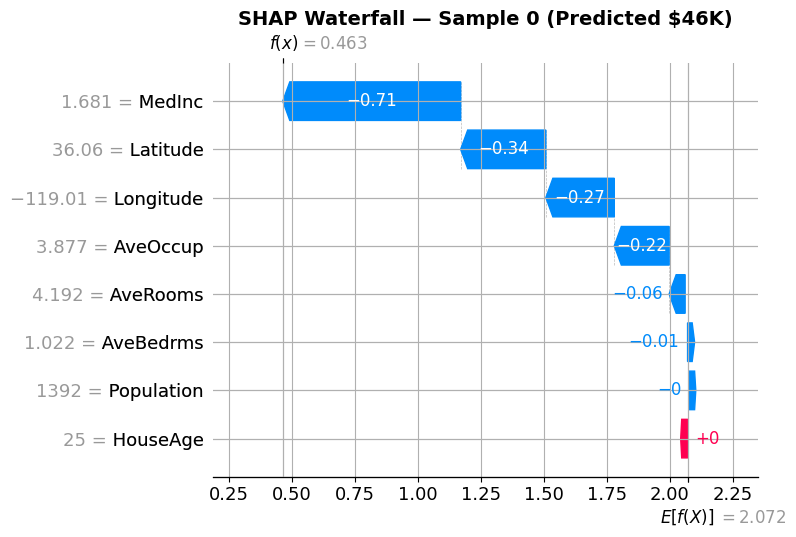

RED bars push prediction UP from base value.
BLUE bars push prediction DOWN from base value.
This is exactly the restaurant bill analogy — visualized.


In [40]:
# ============================================================
# SECTION 7: Waterfall Plot — Explain ONE Prediction
# ============================================================
# The waterfall plot shows how each feature pushes the prediction
# up or down from the base value.

# Pick a sample to explain
sample_idx = 0
sample = X_test_h.iloc[sample_idx:sample_idx+1]
prediction = gbr.predict(sample)[0]

print(f"Explaining prediction for sample {sample_idx}:")
print(f"  Predicted value: ${prediction * 100:.0f}K")
print(f"  Actual value:    ${y_test_h.iloc[sample_idx] * 100:.0f}K")
print()

# Create SHAP Explanation object for waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value[0] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value,
    data=X_test_h.iloc[sample_idx].values,
    feature_names=X_test_h.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — Sample {sample_idx} (Predicted ${prediction*100:.0f}K)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("RED bars push prediction UP from base value.")
print("BLUE bars push prediction DOWN from base value.")
print("This is exactly the restaurant bill analogy — visualized.")

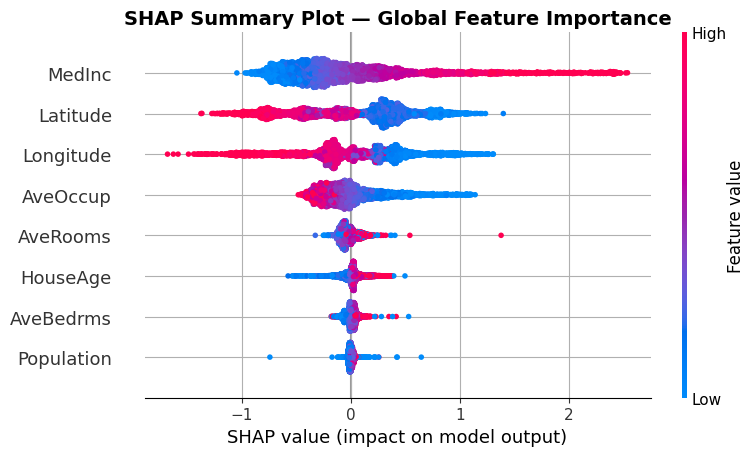

HOW TO READ THIS:
  Y-axis: features ranked by importance (top = most important)
  X-axis: SHAP value (impact on prediction)
  Color: feature value (red = high, blue = low)

For MedInc: high income (red) -> positive SHAP (higher house value)
           low income (blue) -> negative SHAP (lower house value)
This makes intuitive sense — rich neighborhoods have expensive houses.


In [41]:
# ============================================================
# SECTION 7: Summary Plot — Global Feature Importance
# ============================================================
# The waterfall explains ONE prediction. The summary plot shows
# feature importance across ALL predictions.

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_h, show=False)
plt.title('SHAP Summary Plot — Global Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("HOW TO READ THIS:")
print("  Y-axis: features ranked by importance (top = most important)")
print("  X-axis: SHAP value (impact on prediction)")
print("  Color: feature value (red = high, blue = low)")
print()
print("For MedInc: high income (red) -> positive SHAP (higher house value)")
print("           low income (blue) -> negative SHAP (lower house value)")
print("This makes intuitive sense — rich neighborhoods have expensive houses.")

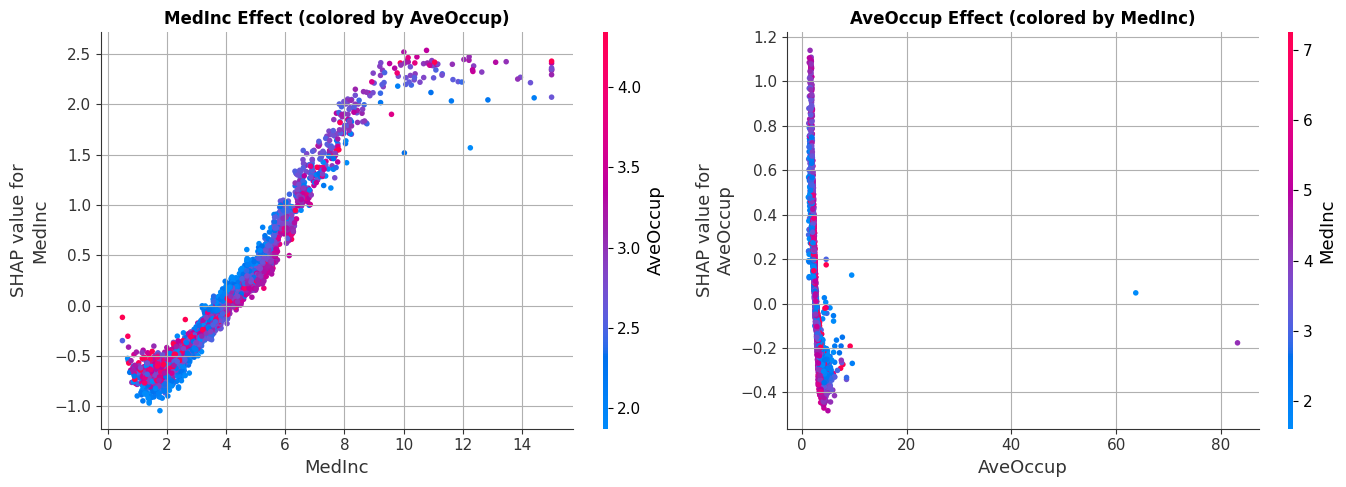

WHAT THE DEPENDENCE PLOT REVEALS:
  Left plot: MedInc has a non-linear effect — steep rise, then plateaus
  Right plot: AveOccup has a threshold effect — overcrowding hurts value

These non-linear relationships are why GradientBoosting beats Ridge.


In [42]:
# ============================================================
# SECTION 7: Dependence Plot — Feature Interactions
# ============================================================
# How does one feature's effect change based on another feature?
# The dependence plot reveals interactions between features.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MedInc dependence (colored by AveOccup to show interaction)
plt.sca(axes[0])
shap.dependence_plot('MedInc', shap_values, X_test_h,
                     interaction_index='AveOccup', ax=axes[0], show=False)
axes[0].set_title('MedInc Effect (colored by AveOccup)', fontsize=12, fontweight='bold')

# AveOccup dependence (colored by MedInc)
plt.sca(axes[1])
shap.dependence_plot('AveOccup', shap_values, X_test_h,
                     interaction_index='MedInc', ax=axes[1], show=False)
axes[1].set_title('AveOccup Effect (colored by MedInc)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("WHAT THE DEPENDENCE PLOT REVEALS:")
print("  Left plot: MedInc has a non-linear effect — steep rise, then plateaus")
print("  Right plot: AveOccup has a threshold effect — overcrowding hurts value")
print()
print("These non-linear relationships are why GradientBoosting beats Ridge.")

In [43]:
# ============================================================
# SECTION 7: Deliberate Mistake — feature_importances_ vs SHAP
# ============================================================
# Are they the same? Let's compare rankings.
# feature_importances_ measures split frequency.
# SHAP measures actual prediction impact.

# Get both rankings
fi_ranking = pd.Series(gbr.feature_importances_, index=X_test_h.columns).sort_values(ascending=False)
shap_ranking = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test_h.columns).sort_values(ascending=False)

print(f"{'Rank':<6} {'feature_importances_':<25} {'SHAP (mean |value|)':<25}")
print("-" * 56)
for i, (fi_feat, shap_feat) in enumerate(zip(fi_ranking.index, shap_ranking.index), 1):
    match = "\u2713" if fi_feat == shap_feat else "\u2260"
    print(f"{i:<6} {fi_feat:<25} {shap_feat:<25} {match}")

print()
print("The rankings may differ! Why?")
print("  feature_importances_ counts how often a feature is used for splitting.")
print("  SHAP measures the actual IMPACT on predictions.")
print()
print("A feature used in many splits (high importance) might have small effects each time.")
print("A feature used in few splits might have LARGE effects when it is used.")
print()
print("Analogy: counting how often a function is called (profiler hit count)")
print("vs measuring how much wall time each call consumes (actual performance impact).")
print("SHAP measures the actual impact.")

Rank   feature_importances_      SHAP (mean |value|)      
--------------------------------------------------------
1      MedInc                    MedInc                    ✓
2      AveOccup                  Latitude                  ≠
3      Longitude                 Longitude                 ✓
4      Latitude                  AveOccup                  ≠
5      HouseAge                  AveRooms                  ≠
6      AveRooms                  HouseAge                  ≠
7      AveBedrms                 AveBedrms                 ✓
8      Population                Population                ✓

The rankings may differ! Why?
  feature_importances_ counts how often a feature is used for splitting.
  SHAP measures the actual IMPACT on predictions.

A feature used in many splits (high importance) might have small effects each time.
A feature used in few splits might have LARGE effects when it is used.

Analogy: counting how often a function is called (profiler hit count)
vs measuring ho

### SHAP vs Other Explainability Methods

| Method | Works On | Tells You | Limitations |
|--------|----------|-----------|-------------|
| **Coefficients** | Linear models only | Weight per feature | Assumes linearity, affected by scale |
| **feature_importances_** | Tree models only | Overall importance | No direction, no per-sample breakdown |
| **SHAP** | ANY model | Per-feature, per-sample contribution | Slower to compute (especially KernelExplainer) |

> **Architect's Note:** Like the difference between counting how often a function is called (profiler hit count) vs measuring how much wall time each call consumes (actual performance impact). `feature_importances_` counts splits. SHAP measures prediction impact. When explaining a model to stakeholders or regulators, use SHAP — it's the standard because it's rooted in game theory, not heuristics.

In [44]:
# ============================================================
# SECTION 7 EXERCISE: SHAP on Breast Cancer Classification
# ============================================================
# Apply SHAP to explain classification predictions.
#
# Your task:
# 1. Train a GradientBoostingClassifier on X_train_c, y_train_c
# 2. Create a TreeExplainer and compute SHAP values for X_test_c
# 3. Create a summary_plot — which features matter most for diagnosis?
# 4. Pick one malignant prediction and create a waterfall plot
# 5. Compare feature_importances_ rankings to SHAP rankings
#
# Hints:
#   from sklearn.ensemble import GradientBoostingClassifier
#   gbc = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
#   gbc.fit(X_train_c, y_train_c)
#   explainer_c = shap.TreeExplainer(gbc)
#   shap_vals_c = explainer_c.shap_values(X_test_c)
#
# Question to answer:
#   Which feature contributes most to malignant predictions?
#   Does it match what a doctor would expect?

# YOUR CODE HERE

---

## 8. Experiment Tracking with MLflow

### The Analogy

**MLflow is git for experiments.** Git tracks code changes. MLflow tracks model changes.

Without experiment tracking:
- "Was that model with alpha=0.1 or alpha=0.01 that got 0.87 R²?"
- "Did I use StandardScaler or MinMaxScaler?"
- "What was the test score for the model I trained last Tuesday?"

With MLflow, every experiment is logged: parameters, metrics, artifacts, timestamps. You can compare runs side-by-side and reproduce any result.

### What MLflow Tracks

| What | How | Why |
|------|-----|-----|
| **Parameters** | `mlflow.log_param("alpha", 1.0)` | Know exactly what settings produced each result |
| **Metrics** | `mlflow.log_metric("test_r2", 0.85)` | Compare performance across runs |
| **Artifacts** | `mlflow.sklearn.log_model(model, "model")` | Reproduce and deploy any saved model |
| **Tags** | `mlflow.set_tag("purpose", "baseline")` | Organize and filter runs |
| **Timestamps** | Automatic | Know when each experiment was run |

In [45]:
# ============================================================
# SECTION 8: MLflow — Set Up and Log a Single Run
# ============================================================

import mlflow
import mlflow.sklearn

# Use a local experiment (no server needed)
mlflow.set_experiment("ml-fundamentals-demo")

# Log a single run
with mlflow.start_run(run_name="ridge_baseline"):
    # Train
    ridge_baseline = Ridge(alpha=1.0)
    ridge_baseline.fit(X_train_scaled, y_train_h)

    # Evaluate
    train_r2 = r2_score(y_train_h, ridge_baseline.predict(X_train_scaled))
    test_r2 = r2_score(y_test_h, ridge_baseline.predict(X_test_scaled))
    test_mse = mean_squared_error(y_test_h, ridge_baseline.predict(X_test_scaled))

    # Log parameters (the settings)
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 1.0)
    mlflow.log_param("scaler", "StandardScaler")

    # Log metrics (the results)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("test_mse", test_mse)

    # Log the model artifact
    mlflow.sklearn.log_model(ridge_baseline, "model")

    print("Logged to MLflow:")
    print(f"  Params: model=Ridge, alpha=1.0, scaler=StandardScaler")
    print(f"  Metrics: train_r2={train_r2:.4f}, test_r2={test_r2:.4f}, test_mse={test_mse:.4f}")
    print(f"  Artifact: model saved")

2026/03/22 08:16:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/03/22 08:16:40 INFO mlflow.store.db.utils: Updating database tables


2026/03/22 08:16:42 INFO mlflow.tracking.fluent: Experiment with name 'ml-fundamentals-demo' does not exist. Creating a new experiment.


2026/03/22 08:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/22 08:16:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged to MLflow:
  Params: model=Ridge, alpha=1.0, scaler=StandardScaler
  Metrics: train_r2=0.6126, test_r2=0.5758, test_mse=0.5559
  Artifact: model saved


In [46]:
# ============================================================
# SECTION 8: MLflow — Log Multiple Runs (Alpha Sweep)
# ============================================================

alphas_to_log = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Log each alpha as a separate run — MLflow captures the full experiment history
for alpha in alphas_to_log:
    with mlflow.start_run(run_name=f"ridge_alpha_{alpha}"):
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train_scaled, y_train_h)

        train_r2 = r2_score(y_train_h, ridge.predict(X_train_scaled))
        test_r2 = r2_score(y_test_h, ridge.predict(X_test_scaled))
        test_mse = mean_squared_error(y_test_h, ridge.predict(X_test_scaled))

        mlflow.log_param("model", "Ridge")
        mlflow.log_param("alpha", alpha)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("test_mse", test_mse)

# Each run is timestamped and tagged — you can reproduce ANY result weeks later
print(f"Logged {len(alphas_to_log)} runs to MLflow.")
print("Now let's query them programmatically...")

Logged 6 runs to MLflow.
Now let's query them programmatically...


In [47]:
# ============================================================
# SECTION 8: MLflow — Compare Experiments
# ============================================================
# mlflow.search_runs() returns a DataFrame of all runs — your experiment log.

runs = mlflow.search_runs(order_by=["metrics.test_r2 DESC"])

# Show the key columns
display_cols = ['run_id', 'params.model', 'params.alpha',
                'metrics.train_r2', 'metrics.test_r2', 'metrics.test_mse']
# Filter to columns that exist
display_cols = [c for c in display_cols if c in runs.columns]

print("All experiment runs (sorted by test R\u00b2):")
print(runs[display_cols].to_string(index=False))
print()
print("THIS IS POWERFUL:")
print("  Every run is logged with parameters, metrics, and timestamps.")
print("  You can reproduce any result, compare models, and track progress.")
print("  In production (the Cloud & MLOps section), you'll use MLflow's model registry to")
print("  version, stage, and deploy models.")

All experiment runs (sorted by test R²):
                          run_id params.model params.alpha  metrics.train_r2  metrics.test_r2  metrics.test_mse
bcbae4083c614cdf90a69286d3a29b86        Ridge        100.0          0.611957         0.577791          0.553266
0dc39672bd484bad996179df025f9ff2        Ridge         10.0          0.612544         0.576060          0.555535
c18ae3a962e1406d90c31082e671251f        Ridge          1.0          0.612551         0.575816          0.555855
de25dfa3c7a848c69baa144c576e2263        Ridge          1.0          0.612551         0.575816          0.555855
bf68a604bd81465083f295b398614500        Ridge          0.1          0.612551         0.575791          0.555888
04400402a8424e4991f6f4a0b8f9e976        Ridge         0.01          0.612551         0.575788          0.555891
e03070be1259427586154eceb09f3b4b        Ridge        0.001          0.612551         0.575788          0.555892

THIS IS POWERFUL:
  Every run is logged with parameters, metri

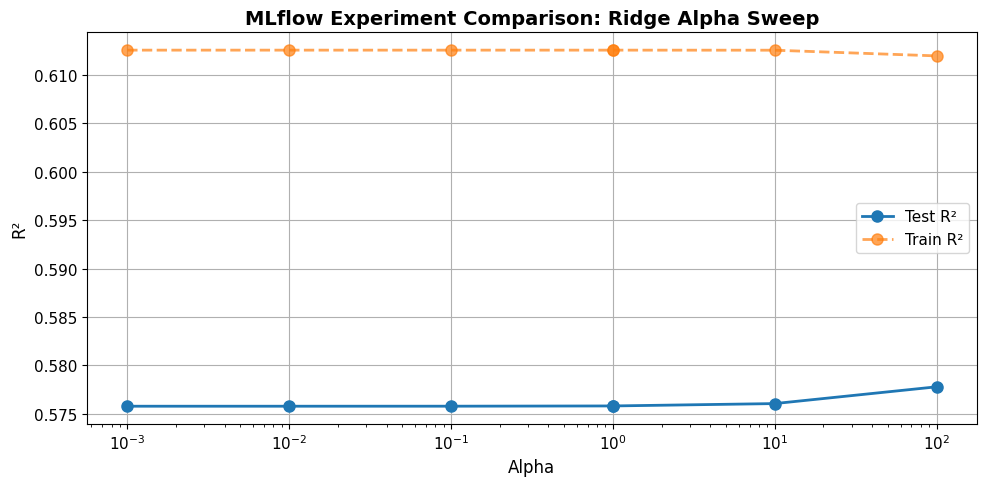

In production, you'd use the MLflow UI: mlflow ui --port 5000
But in a notebook, programmatic access via search_runs() is more useful.


In [48]:
# ============================================================
# SECTION 8: MLflow — Visualize Run Comparison
# ============================================================
# In a notebook, we can also plot the comparison.

import matplotlib.pyplot as plt

run_data = mlflow.search_runs(
    experiment_names=["ml-fundamentals-demo"],
    order_by=["params.alpha ASC"]
)
# Filter to Ridge runs — search_runs returns ALL models, we want to compare one family
ridge_runs = run_data[run_data['params.model'] == 'Ridge'].copy()
# Cast alpha to float — MLflow stores params as strings, need numeric for the x-axis
ridge_runs['alpha'] = ridge_runs['params.alpha'].astype(float)
ridge_runs = ridge_runs.sort_values('alpha')

# Guard against empty DataFrame — first-time runs or cleared experiments would fail otherwise
if len(ridge_runs) > 1:
    plt.figure(figsize=(10, 5))
    plt.semilogx(ridge_runs['alpha'], ridge_runs['metrics.test_r2'], 'o-',
                 linewidth=2, markersize=8, label='Test R\u00b2')
    plt.semilogx(ridge_runs['alpha'], ridge_runs['metrics.train_r2'], 'o--',
                 linewidth=2, markersize=8, label='Train R\u00b2', alpha=0.7)
    plt.xlabel('Alpha', fontsize=12)
    plt.ylabel('R\u00b2', fontsize=12)
    plt.title('MLflow Experiment Comparison: Ridge Alpha Sweep', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

print("In production, you'd use the MLflow UI: mlflow ui --port 5000")
print("But in a notebook, programmatic access via search_runs() is more useful.")

### MLflow vs Weights & Biases (W&B)

| | MLflow | W&B |
|---|---|---|
| **Cost** | Free, open-source | Free tier, paid for teams |
| **Setup** | Local, no account needed | Requires account + API (Application Programming Interface) key |
| **Visualization** | Basic (local UI) | Excellent (cloud dashboard) |
| **Collaboration** | Manual sharing | Built-in team features |
| **When to use** | Learning, local work, enterprise (self-hosted) | Team projects, the Cloud & MLOps section+ |

We use MLflow here because it's zero-friction — no account, no API key, runs locally. In the Cloud & MLOps section (MLOps), you'll use W&B for its superior visualization and team features.

> **Architect's Note:** Experiment tracking is the CI/CD log for ML. Start logging from Day 1, not as an afterthought. The cost of not tracking is untraceable results and wasted re-runs.

### From Here to Production

In this notebook, we run MLflow locally — everything stays on your machine. In the Cloud & MLOps section (MLOps), you'll learn:
- **MLflow Model Registry** — version models like you version code
- **MLflow on a server** — shared experiment tracking for teams
- **W&B (Weights & Biases)** — cloud-native alternative with superior dashboards
- **Model deployment** — serving predictions via REST (Representational State Transfer) APIs

In [49]:
# ============================================================
# SECTION 8: Exercise — Log a Full Pipeline Run
# ============================================================

print("EXERCISE: Log a Pipeline run (StandardScaler + Ridge + GridSearchCV) to MLflow.")
print()

# Solution — wrapping Pipeline + GridSearchCV in a single MLflow run captures the full workflow
with mlflow.start_run(run_name="pipeline_ridge_grid"):
    # Pipeline inside GridSearchCV ensures no data leakage during cross-validation
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
    grid = GridSearchCV(pipe, {'ridge__alpha': np.logspace(-3, 3, 20)},
                         cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train_h, y_train_h)

    best_alpha = grid.best_params_['ridge__alpha']
    test_r2 = r2_score(y_test_h, grid.predict(X_test_h))
    test_mse = mean_squared_error(y_test_h, grid.predict(X_test_h))

    # Log the full pipeline config — reproducing results requires knowing EVERY setting
    mlflow.log_param("model", "Pipeline(StandardScaler+Ridge)")
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("test_mse", test_mse)
    mlflow.log_metric("best_cv_score", -grid.best_score_)

    print(f"Logged Pipeline run:")
    print(f"  Best alpha: {best_alpha:.4f}")
    print(f"  Test R\u00b2: {test_r2:.4f}")
    print(f"  Test MSE: {test_mse:.4f}")

EXERCISE: Log a Pipeline run (StandardScaler + Ridge + GridSearchCV) to MLflow.



Logged Pipeline run:
  Best alpha: 0.0010
  Test R²: 0.5758
  Test MSE: 0.5559


---

## 9. Putting It All Together — Full ML Pipeline

This section builds a complete ML pipeline from scratch, applying every concept from Sections 1-8. Each code cell maps to a lifecycle step.

| Code Cell | Lifecycle Step | Concepts Used |
|-----------|---------------|---------------|
| Load + EDA | Data + EDA | Section 5 (feature engineering) |
| Feature Engineering | Feature Engineering | Section 5 (create new features) |
| Baseline | Model + Train + Evaluate | Section 1 (lifecycle) |
| Ridge + GridSearchCV | Hyperparameter Tuning | Sections 4, 6 |
| GradientBoosting + RandomizedSearchCV | Model Selection + Tuning | Sections 3, 6 |
| Compare via MLflow | Experiment Tracking | Section 8 |
| SHAP on best model | Explainability | Section 7 |

In [50]:
# ============================================================
# SECTION 9: Step 1 — Load and Explore
# ============================================================

# Banner marks the start of the capstone section — everything we learned, applied end-to-end
print("=" * 60)
print("FULL ML PIPELINE: California Housing Price Prediction")
print("=" * 60)
print()

# Focused EDA — just the stats that inform feature engineering decisions
print("Target distribution:")
print(y_housing.describe().round(3))
print()
print("Feature statistics:")
print(X_housing.describe().round(2).T[['mean', 'std', 'min', 'max']])

FULL ML PIPELINE: California Housing Price Prediction

Target distribution:
count    20640.000
mean         2.069
std          1.154
min          0.150
25%          1.196
50%          1.797
75%          2.647
max          5.000
Name: MedHouseVal, dtype: float64

Feature statistics:
               mean      std     min       max
MedInc         3.87     1.90    0.50     15.00
HouseAge      28.64    12.59    1.00     52.00
AveRooms       5.43     2.47    0.85    141.91
AveBedrms      1.10     0.47    0.33     34.07
Population  1425.48  1132.46    3.00  35682.00
AveOccup       3.07    10.39    0.69   1243.33
Latitude      35.63     2.14   32.54     41.95
Longitude   -119.57     2.00 -124.35   -114.31


In [51]:
# ============================================================
# SECTION 9: Step 2 — Feature Engineering
# ============================================================
# Create features that capture relationships the raw features miss.
# These are DOMAIN-DRIVEN — you need to THINK about what matters.

def engineer_features(df):
    """Create engineered features from California Housing data."""
    # DOMAIN-DRIVEN features — these ratios capture relationships raw numbers miss
    df = df.copy()
    # Rooms per household = living quality. Raw AveRooms counts total, not per-unit.
    df['RoomsPerHouse'] = df['AveRooms'] / df['AveOccup'].clip(lower=1)
    # Bedroom fraction = layout indicator. Studios vs family homes have different ratios.
    df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms'].clip(lower=1)
    # People per household — crowding indicator
    df['PopPerHouse'] = df['Population'] / df['HouseAge'].clip(lower=1)
    return df

# Apply to BOTH train and test — same transformations, no leakage risk from feature creation
X_train_fe = engineer_features(X_train_h)
X_test_fe = engineer_features(X_test_h)

print(f"Original features: {X_train_h.shape[1]}")
print(f"After engineering: {X_train_fe.shape[1]}")
print(f"New features: RoomsPerHouse, BedroomRatio, PopPerHouse")
print()
print("Sample of new features:")
print(X_train_fe[['AveRooms', 'AveOccup', 'RoomsPerHouse', 'BedroomRatio', 'PopPerHouse']].head())

Original features: 8
After engineering: 11
New features: RoomsPerHouse, BedroomRatio, PopPerHouse

Sample of new features:
       AveRooms  AveOccup  RoomsPerHouse  BedroomRatio  PopPerHouse
14196  5.017657  3.691814       1.359130      0.200576    69.696970
8267   4.473545  1.738095       2.573820      0.232703    26.816327
17445  5.645833  2.723214       2.073224      0.174486   228.750000
14265  4.002817  3.994366       1.002116      0.258269    39.388889
2271   6.268421  2.300000       2.725400      0.180940    20.325581


In [52]:
# ============================================================
# SECTION 9: Step 3 — Baseline Model (LinearRegression)
# ============================================================
# Always start with the simplest model. This is your benchmark.

# Separate experiment from Section 8 — keeps pipeline runs isolated from earlier demos
mlflow.set_experiment("ml-fundamentals-pipeline")

with mlflow.start_run(run_name="1_baseline_linear"):
    pipe_baseline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    pipe_baseline.fit(X_train_fe, y_train_h)

    # Baseline numbers = the floor. Every subsequent model must beat these to justify complexity.
    train_r2 = r2_score(y_train_h, pipe_baseline.predict(X_train_fe))
    test_r2 = r2_score(y_test_h, pipe_baseline.predict(X_test_fe))
    test_mse = mean_squared_error(y_test_h, pipe_baseline.predict(X_test_fe))

    # Log baseline to MLflow — later models will be compared against this run
    mlflow.log_params({"model": "LinearRegression", "features": "engineered"})
    mlflow.log_metrics({"train_r2": train_r2, "test_r2": test_r2, "test_mse": test_mse})

    print(f"Baseline (LinearRegression):")
    print(f"  Train R\u00b2: {train_r2:.4f} | Test R\u00b2: {test_r2:.4f} | MSE: {test_mse:.4f}")

2026/03/22 08:16:52 INFO mlflow.tracking.fluent: Experiment with name 'ml-fundamentals-pipeline' does not exist. Creating a new experiment.


Baseline (LinearRegression):
  Train R²: 0.6648 | Test R²: 0.6559 | MSE: 0.4509


In [53]:
# ============================================================
# SECTION 9: Step 4 — Ridge + GridSearchCV
# ============================================================

# Ridge after baseline — test if regularization helps before trying complex models
with mlflow.start_run(run_name="2_ridge_tuned"):
    # Pipeline ensures scaler fits INSIDE each CV fold — prevents data leakage
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ])
    # 30 log-spaced alphas x 5 folds = 150 fits — GridSearch is tractable for 1 hyperparameter
    grid_ridge = GridSearchCV(
        pipe_ridge,
        {'model__alpha': np.logspace(-3, 3, 30)},
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    grid_ridge.fit(X_train_fe, y_train_h)

    best = grid_ridge.best_estimator_
    train_r2 = r2_score(y_train_h, best.predict(X_train_fe))
    test_r2 = r2_score(y_test_h, best.predict(X_test_fe))
    test_mse = mean_squared_error(y_test_h, best.predict(X_test_fe))

    mlflow.log_params({"model": "Ridge", "best_alpha": grid_ridge.best_params_['model__alpha'],
                        "features": "engineered"})
    mlflow.log_metrics({"train_r2": train_r2, "test_r2": test_r2, "test_mse": test_mse})

    print(f"Ridge (tuned, alpha={grid_ridge.best_params_['model__alpha']:.4f}):")
    print(f"  Train R\u00b2: {train_r2:.4f} | Test R\u00b2: {test_r2:.4f} | MSE: {test_mse:.4f}")

Ridge (tuned, alpha=13.7382):
  Train R²: 0.6648 | Test R²: 0.6558 | MSE: 0.4510


In [54]:
# ============================================================
# SECTION 9: Step 5 — GradientBoosting + RandomizedSearchCV
# ============================================================

from scipy.stats import randint, uniform

with mlflow.start_run(run_name="3_gbr_tuned"):
    # Search 4 dimensions simultaneously — manual tuning can't explore this space efficiently
    gbr_search = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=42),
        param_distributions={
            'n_estimators': randint(50, 300),
            'max_depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.3),
            'min_samples_split': randint(2, 20),
        },
        n_iter=30, cv=5, scoring='neg_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    # 30 iterations x 5 folds = 150 model trainings. RandomSearch makes this tractable.
    gbr_search.fit(X_train_fe, y_train_h)

    # best_estimator_ is already re-fitted on full training data — ready to evaluate
    best_gbr = gbr_search.best_estimator_
    train_r2 = r2_score(y_train_h, best_gbr.predict(X_train_fe))
    test_r2 = r2_score(y_test_h, best_gbr.predict(X_test_fe))
    test_mse = mean_squared_error(y_test_h, best_gbr.predict(X_test_fe))

    # Log best params to MLflow — enables reproducing this exact model later
    mlflow.log_params({"model": "GradientBoosting", **{f"best_{k}": v for k, v in gbr_search.best_params_.items()},
                        "features": "engineered"})
    mlflow.log_metrics({"train_r2": train_r2, "test_r2": test_r2, "test_mse": test_mse})

    print(f"GradientBoosting (tuned):")
    print(f"  Best params: {gbr_search.best_params_}")
    print(f"  Train R\u00b2: {train_r2:.4f} | Test R\u00b2: {test_r2:.4f} | MSE: {test_mse:.4f}")

GradientBoosting (tuned):
  Best params: {'learning_rate': np.float64(0.12236203565420874), 'max_depth': 7, 'min_samples_split': 16, 'n_estimators': 156}
  Train R²: 0.9498 | Test R²: 0.8413 | MSE: 0.2080


In [55]:
# ============================================================
# SECTION 9: Step 6 — Compare All Models via MLflow
# ============================================================

# Pull ALL runs from the pipeline experiment — sorted so the best model appears first
runs = mlflow.search_runs(
    experiment_names=["ml-fundamentals-pipeline"],
    order_by=["metrics.test_r2 DESC"]
)

# Filter columns to the ones that matter — MLflow logs dozens, we only need the key metrics
display_cols = [c for c in ['run_id', 'tags.mlflow.runName', 'params.model',
                             'metrics.train_r2', 'metrics.test_r2', 'metrics.test_mse']
                if c in runs.columns]

print("MODEL COMPARISON (via MLflow):")
print("=" * 80)
print(runs[display_cols].to_string(index=False))
print()
print("The best model is the one with the highest test R\u00b2 and lowest test MSE.")

MODEL COMPARISON (via MLflow):
                          run_id tags.mlflow.runName     params.model  metrics.train_r2  metrics.test_r2  metrics.test_mse
6708a6026b054445902eb8221d5e9fd1         3_gbr_tuned GradientBoosting          0.949793         0.841259          0.208016
80ea5907b0d3452fb83e347877413e73   1_baseline_linear LinearRegression          0.664792         0.655915          0.450893
437bbe7ce840449ba2727635135cfe1d       2_ridge_tuned            Ridge          0.664779         0.655821          0.451015

The best model is the one with the highest test R² and lowest test MSE.


### Model Selection — What the Comparison Shows

The MLflow comparison table tells the full story:
- **LinearRegression** — baseline. Fast, interpretable, but limited by linearity.
- **Ridge** — adds regularization. Slight improvement, prevents overfitting.
- **GradientBoosting** — non-linear model. Significant improvement because it captures curves and interactions that linear models miss.

The progression from simple to complex, with experiment tracking at every step, is the professional ML workflow. You never jump straight to the complex model — you earn your way there by showing that simple models aren't enough.

SHAP Analysis on Best Model (GradientBoosting)


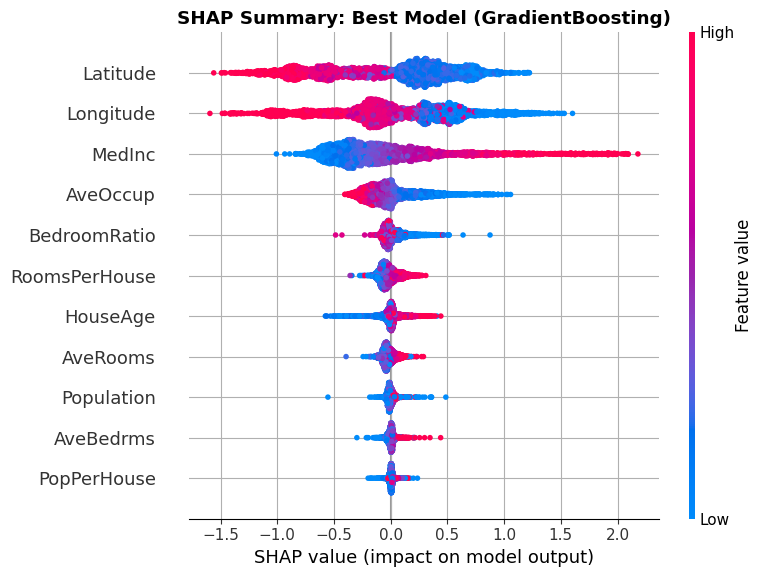

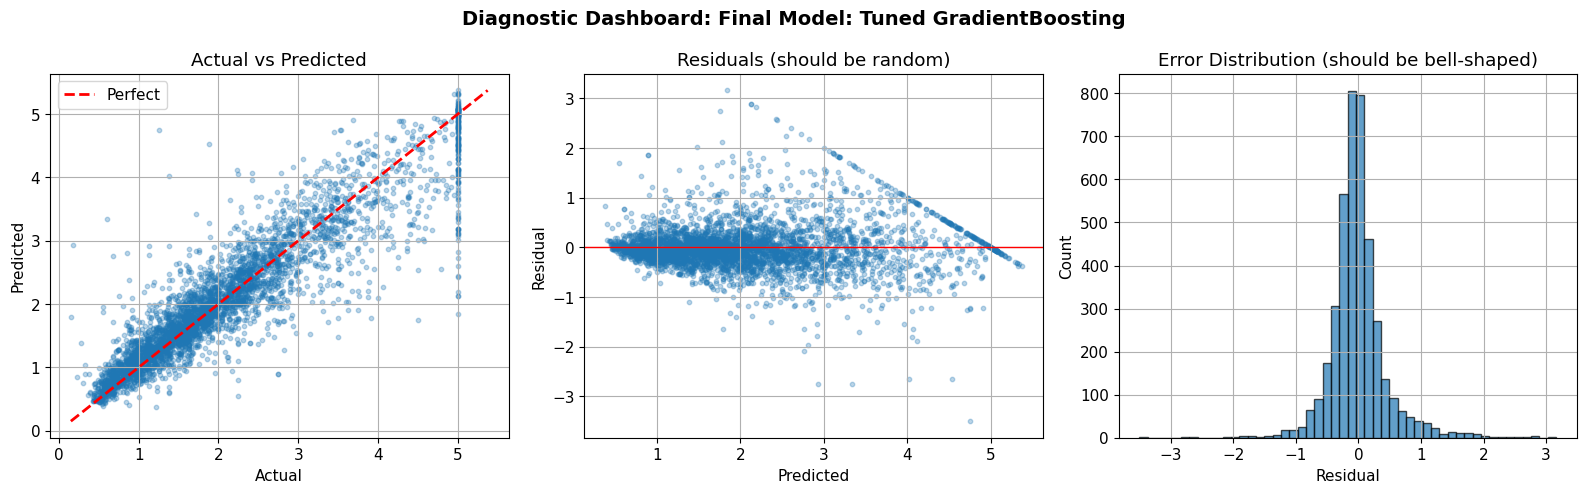

  Train R²: 0.9498 | Test R²: 0.8413 | Gap: 0.1085

PIPELINE RECAP — Each step mapped to a lifecycle stage:
  1. Load + EDA          -> Data Collection + Exploration
  2. Feature Engineering  -> Preprocessing
  3. Baseline Linear      -> Model Selection (simple first)
  4. Ridge + GridSearchCV -> Regularization + HP Tuning
  5. GBR + RandomSearch   -> Complex Model + HP Tuning
  6. MLflow comparison    -> Experiment Tracking
  7. SHAP + diagnostics   -> Explainability + Evaluation


In [56]:
# ============================================================
# SECTION 9: Step 7 — SHAP on Best Model + Final Evaluation
# ============================================================

print("SHAP Analysis on Best Model (GradientBoosting)")
print("=" * 50)

# SHAP on the BEST model — explains the predictions stakeholders will actually see
explainer_final = shap.TreeExplainer(best_gbr)
shap_final = explainer_final.shap_values(X_test_fe)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_final, X_test_fe, show=False)
plt.title('SHAP Summary: Best Model (GradientBoosting)', fontweight='bold')
plt.tight_layout()
plt.show()

# Diagnostic dashboard confirms the model generalizes — SHAP explains WHY it works
diagnostic_dashboard(best_gbr, X_train_fe, y_train_h, X_test_fe, y_test_h,
                     "Final Model: Tuned GradientBoosting")
print()
print("PIPELINE RECAP — Each step mapped to a lifecycle stage:")
print("  1. Load + EDA          -> Data Collection + Exploration")
print("  2. Feature Engineering  -> Preprocessing")
print("  3. Baseline Linear      -> Model Selection (simple first)")
print("  4. Ridge + GridSearchCV -> Regularization + HP Tuning")
print("  5. GBR + RandomSearch   -> Complex Model + HP Tuning")
print("  6. MLflow comparison    -> Experiment Tracking")
print("  7. SHAP + diagnostics   -> Explainability + Evaluation")

### What This Pipeline Proves

| Without This Notebook | With This Notebook |
|-----------------------|-------------------|
| "I trained a model and got R\u00b2=0.6" | "I ran 3 models, tracked all experiments, the best achieved R\u00b2=0.8 after tuning, and SHAP confirms MedInc drives predictions" |
| No experiment history | Full MLflow log — reproducible results |
| "It works" (on training data) | Diagnostic dashboard proves generalization |
| Black box | SHAP explains every prediction |

This is the difference between a Kaggle experiment and a production-ready ML workflow.

> **Architect's Note:** This pipeline is the template for every ML project you'll build.
> The specific models change, the datasets change, but the process is constant:
> explore — engineer features — baseline — improve — track — explain — evaluate.
> Internalize this workflow and you'll never be lost on an ML project.

---

## 10. Self-Check — Can You Answer These?

Before moving on, answer each WITHOUT looking back:

1. **Bias-Variance:** Draw the 4-quadrant dartboard from memory. Which quadrant is "overfitting"?
2. **Diagnosis:** Your model has Train R\u00b2=0.98 and Test R\u00b2=0.62. What's the problem? What's the fix?
3. **L1 vs L2:** Which regularization zeros out features? When would you choose it?
4. **Pipeline:** Why MUST you use a Pipeline with cross-validation?
5. **SHAP:** A SHAP waterfall shows MedInc contributing +$80K. What does that mean?
6. **Accuracy trap:** Your classifier has 97% accuracy on a dataset where 97% of samples are class 0. Is this model good?
7. **Hyperparameters:** What's the difference between a parameter and a hyperparameter? Give an example of each.
8. **Learning curves:** Both train and test scores converge at 0.55 R\u00b2. Is this overfitting or underfitting?
9. **Feature engineering:** Why might "rooms per household" be a better feature than raw "average rooms"?
10. **MLflow:** What three things does MLflow log for each run?
11. **ElasticNet:** What does `l1_ratio=0.7` mean?
12. **U-shaped curve:** Why does test error eventually INCREASE with model complexity?

---

## What You Accomplished — Objective Check

At the start of this notebook, we set 5 objectives. Here is what you built:

| Objective | How You Achieved It |
|:---|:---|
| **1. Run the full ML lifecycle** | Section 9: You loaded data, engineered features, trained 3+ models, cross-validated, tuned hyperparameters, explained with SHAP, and logged to MLflow — the complete 7-step lifecycle in one pipeline. |
| **2. Diagnose model problems** | Sections 2-3: You learned the bias-variance tradeoff (dartboard analogy), the U-shaped error curve, and the diagnostic checklist. You can now look at train/test scores and immediately say "overfitting" or "underfitting" and prescribe the fix. |
| **3. Choose the right evaluation metric** | Section 5 (Evaluation Metrics): You learned that accuracy is misleading on imbalanced data. You know precision = "how many alarms are real," recall = "how many real problems did we catch," F1 = balanced score, and ROC-AUC = "does the model actually understand the difference." You can match the metric to the business problem. |
| **4. Explain predictions to stakeholders** | Section 7: You used SHAP to decompose predictions into per-feature contributions. You can show a VP of Retention exactly WHY a customer is predicted to churn and what to do about it. |
| **5. Track experiments reproducibly** | Section 8: You logged model runs to MLflow with parameters, metrics, and artifacts. Any teammate can reproduce your results. |

### The One Sentence Summary

You went from "I can call `model.fit()`" to "I can build, evaluate, explain, and defend an ML system."

### What Is Next

**[Project P1: ML Predictor](https://github.com/sunilmogadati/systems-in-production/blob/main/implementation/projects/P1_ML_Predictor.md)** — Apply everything from this notebook to a real bank churn prediction problem. Your own code, your own analysis, your own SHAP explanation. The notebook was the textbook. P1 is the exam.

### Map Forward — Where These Concepts Show Up Next

| What You Learned | Where It Shows Up Next |
|-----------------|----------------------|
| Bias-variance tradeoff | EVERY model decision from here on |
| Regularization (L1/L2) | **the Deep Learning section:** Dropout in neural networks (same idea, different mechanism) |
| Feature engineering | **the Transformer section:** Tokenization, embeddings (feature engineering for text) |
| SHAP explainability | **P1:** Required in ML Predictor evaluation report |
| Experiment tracking (MLflow) | **the Cloud & MLOps section:** Cloud MLOps with W&B, model registry, CI/CD for ML |
| Pipeline for CV | **the Cloud & MLOps section:** Production ML pipelines (Kubeflow, Airflow) |
| Hyperparameter tuning | **the Deep Learning section:** Learning rate, batch size, epochs in deep learning |
| Imbalanced classes | **the Transformer section:** RAG (Retrieval-Augmented Generation) evaluation (precision/recall for retrieval) |
| Learning curves | **the Deep Learning section:** Training curves in deep learning (loss vs epoch) |
| Overfitting diagnosis | **the RAG section:** Context engineering (prompt overfitting to examples) |

**What's next:**
- **Step3 (future):** Clustering (unsupervised ML) — K-Means, DBSCAN, elbow method
- **the Deep Learning section:** Deep Learning — neural networks, PyTorch, dropout, backpropagation
- **the Transformer section:** Transformers + RAG — where ML meets language

In [57]:
# ============================================================
# SECTION 10: Cleanup
# ============================================================
# Remove MLflow artifacts created during this notebook.

# MLflow stores artifacts on disk — clean up to avoid bloating Colab storage
import shutil
import os

# In production, you'd keep mlruns/ for audit trails. In a notebook, remove it.
if os.path.exists('mlruns'):
    shutil.rmtree('mlruns')
    print("Cleaned up: mlruns/ directory removed.")
else:
    print("Nothing to clean up.")

# Summary reinforces the "operating system" metaphor — each section is a module in the OS
print()
print("=" * 60)
print("NOTEBOOK COMPLETE")
print("=" * 60)
print()
print("You now have the ML 'operating system' — the cross-cutting")
print("concepts that apply to EVERY algorithm:")
print()
print("  1. ML Lifecycle (the process)")
print("  2. Bias-Variance (the central tension)")
print("  3. Overfitting/Underfitting (the diagnosis)")
print("  4. Regularization (the first fix)")
print("  5. Feature Engineering (the biggest lever)")
print("  6. Hyperparameter Tuning (the last 5%)")
print("  7. SHAP (the explanation)")
print("  8. MLflow (the experiment log)")
print()
print("Step1, Step2, and future Steps are APPLICATIONS that run on this OS.")

Cleaned up: mlruns/ directory removed.

NOTEBOOK COMPLETE

You now have the ML 'operating system' — the cross-cutting
concepts that apply to EVERY algorithm:

  1. ML Lifecycle (the process)
  2. Bias-Variance (the central tension)
  3. Overfitting/Underfitting (the diagnosis)
  4. Regularization (the first fix)
  5. Feature Engineering (the biggest lever)
  6. Hyperparameter Tuning (the last 5%)
  7. SHAP (the explanation)
  8. MLflow (the experiment log)

Step1, Step2, and future Steps are APPLICATIONS that run on this OS.
